# CRISP: Channel-Randomised Single-Image Steganography with Permutations

Reference implementation with full step-by-step output.

A client (**Alice**) hides Boolean inputs in the least-significant bits of cover images. An honest-but-curious cloud (**Carol**) evaluates a Fredkin-gate circuit over *every pixel* of those images, so she processes the secret without knowing which pixel holds it. A receiver (**Bob**) extracts the result at a secret pixel position known only to the endpoints.

| Section | What it shows |
|---|---|
| 1-4 | Circuit model, primitives, the two repairs, the parties |
| 5 | Your cover images, and whether they are suitable |
| 6 | A full verbose run on those covers |
| 7 | Correctness: 288 unit tests and the 8-row truth table |
| 8 | The images themselves, and their LSB planes |
| 9 | Positional security, and the attack that breaks it without R2 |
| 10 | Benchmarks: timing, image count, steganalysis, security, end-to-end |

**What CRISP does not provide: circuit privacy.** Carol holds both channel permutations because she needs them to evaluate and to route, so she reads the channel-to-role map at every gate directly. An adversary holding only the images recovers the same map and the wiring graph with nine channel-pair comparisons per gate. Nothing about the circuit is hidden, and nothing here works around that.

## 0. Setup

In [1]:
import itertools
import os
import random
import re
import string
import tempfile
import time
from collections import defaultdict
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

ALL_PERMS: List[Tuple[int, int, int]] = list(itertools.permutations([0, 1, 2]))
GATE_TYPES = {"FREDKIN": 3}

SHOW_FIGURES = True   # False = headless; figures go to your OS temp dir

print("ready |", len(ALL_PERMS), "permutations in S3")

ready | 6 permutations in S3


## 1. Circuit model

A circuit is a list of Fredkin gates over named wires: primary inputs, ancillaries carrying a fixed public constant, and gate outputs. The Fredkin gate is universal and reversible. It passes the control through unchanged and swaps the two data bits when the control is 1.

In [2]:
class Circuit:
    """Plain container for parsed circuit elements."""

    def __init__(self):
        self.inputs: List[str] = []
        self.ancillaries: List[Tuple[str, int]] = []
        self.gates: List[Dict] = []
        self.outputs: List[str] = []

    def add_input(self, name):
        self.inputs.append(name)

    def add_ancillary(self, name, value):
        self.ancillaries.append((name, value))

    def add_gate(self, gate_type, ins, outs):
        self.gates.append({"type": gate_type, "inputs": ins, "outputs": outs})

    def add_output(self, name):
        self.outputs.append(name)


def parse_circuit(spec: str) -> Circuit:
    """Parse a circuit specification in the standard ProSt format."""
    circuit = Circuit()
    for line in spec.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        tokens = line.split()
        if tokens[0] == "INPUT":
            for name in "".join(tokens[1:]).split(","):
                circuit.add_input(name.strip())
        elif tokens[0] == "ANCILLARY":
            for part in "".join(tokens[1:]).split(","):
                wire, value = part.split("=")
                circuit.add_ancillary(wire.strip(), int(value.strip()))
        elif tokens[0] in GATE_TYPES:
            gate_type = tokens[0]
            expected_io = GATE_TYPES[gate_type]
            arrow_idx = tokens.index("->")
            ins = [x.strip()
                   for x in "".join(tokens[1:arrow_idx]).split(",")]
            outs = [x.strip()
                    for x in "".join(tokens[arrow_idx + 1:]).split(",")]
            if len(ins) != expected_io or len(outs) != expected_io:
                raise ValueError(
                    f"{gate_type} gate must have {expected_io} I/O wires")
            circuit.add_gate(gate_type, ins, outs)
        elif tokens[0] == "OUTPUT":
            for name in "".join(tokens[1:]).split(","):
                circuit.add_output(name.strip())
    return circuit

In [3]:
def build_dependency_graph(gates):
    """Construct a dependency graph keyed by gate index."""
    graph = defaultdict(list)
    in_degree = defaultdict(int)
    wire_to_gate = defaultdict(list)
    for i, gate in enumerate(gates):
        for out in gate["outputs"]:
            wire_to_gate[out].append(i)
    for i, gate in enumerate(gates):
        for inp in gate["inputs"]:
            for producer in wire_to_gate[inp]:
                graph[producer].append(i)
                in_degree[i] += 1
    sources = [i for i in range(len(gates)) if in_degree[i] == 0]
    return graph, in_degree, sources


def randomized_topological_sort(gates):
    """Return a random valid topological order of gate indices."""
    graph, in_degree, sources = build_dependency_graph(gates)
    order = []
    while sources:
        gate_idx = random.choice(sources)
        order.append(gate_idx)
        sources.remove(gate_idx)
        for dep in graph[gate_idx]:
            in_degree[dep] -= 1
            if in_degree[dep] == 0:
                sources.append(dep)
    if len(order) != len(gates):
        raise ValueError("Circuit contains a cycle or invalid dependencies")
    return order


def get_all_wires(circuit_spec: str):
    """Extract every wire name from a circuit specification."""
    all_wires = set()
    for line in circuit_spec.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        tokens = line.split()
        if tokens[0] == "INPUT":
            for name in "".join(tokens[1:]).split(","):
                all_wires.add(name.strip())
        elif tokens[0] == "ANCILLARY":
            for part in "".join(tokens[1:]).split(","):
                wire, _ = part.split("=")
                all_wires.add(wire.strip())
        elif tokens[0] in GATE_TYPES:
            arrow_idx = tokens.index("->")
            ins = [x.strip()
                   for x in "".join(tokens[1:arrow_idx]).split(",")]
            outs = [x.strip()
                    for x in "".join(tokens[arrow_idx + 1:]).split(",")]
            all_wires.update(ins + outs)
        elif tokens[0] == "OUTPUT":
            for name in "".join(tokens[1:]).split(","):
                all_wires.add(name.strip())
    return all_wires

In [4]:
def fredkin(c: int, x: int, y: int) -> Tuple[int, int, int]:
    """The classical Fredkin (controlled-swap) gate.

    F(c, x, y) = (c, x, y)         if c == 0
               = (c, y, x)         if c == 1

    The control bit c always passes through unchanged. This pass-through
    property is precisely what enables the per-channel correlation attack
    of Theorem 2 (Necessity); CRISP's per-gate fresh pi_out is what
    defeats it.
    """
    return (c, y, x) if c == 1 else (c, x, y)


print("Fredkin truth table")
for c, x, y in itertools.product([0, 1], repeat=3):
    print(f"  F({c},{x},{y}) = {fredkin(c, x, y)}"
          f"{'   <- control set, data swapped' if c else ''}")

Fredkin truth table
  F(0,0,0) = (0, 0, 0)
  F(0,0,1) = (0, 0, 1)
  F(0,1,0) = (0, 1, 0)
  F(0,1,1) = (0, 1, 1)
  F(1,0,0) = (1, 0, 0)   <- control set, data swapped
  F(1,0,1) = (1, 1, 0)   <- control set, data swapped
  F(1,1,0) = (1, 0, 1)   <- control set, data swapped
  F(1,1,1) = (1, 1, 1)   <- control set, data swapped


## 2. Primitives

| Function | Caller | Role |
|---|---|---|
| `locgen` | Alice | sample the secret pixel |
| `perm_gen` | Alice | sample `(pi_in, pi_out)` for one gate |
| `randomise_lsb_plane` | Alice | **repair R1** |
| `emb_bit` | Alice | write one LSB at the secret pixel |
| `assemble_stego` | Carol | per-pixel channel routing |
| `comp` | Carol | pixel-wise Fredkin pass |
| `ext_bit` | Bob | read one LSB at the secret pixel |

### Repair R1

Without R1 the decoys at every pixel other than the secret one are the cover's natural LSBs. Natural LSB planes are spatially correlated and biased while the embedded bit is uniform and independent, and that mismatch is the signal RS and sample-pair steganalysis exploit. R1 overwrites the plane with fresh uniform bits first, turning the i.i.d. decoy model from an assumption about photographs into a property of the scheme.

In [5]:
def perm_gen() -> Tuple[Tuple[int, int, int], Tuple[int, int, int]]:
    """Sample two independent uniform-random permutations from S_3.

    Each Fredkin gate uses a fresh pair (pi_in, pi_out). Both are public
    (Carol receives them as part of the circuit specification) but
    independent across gates. The independence is essential: see
    Theorem 2 (Necessity of Per-Gate Resampling).
    """
    return ALL_PERMS[random.randrange(6)], ALL_PERMS[random.randrange(6)]


def locgen(image_shape: Tuple[int, int, int],
           verbose: bool = True,
           interactive: bool = True) -> Tuple[int, int]:
    """Alice samples or accepts the secret pixel position.

    The secret never leaves Alice and Bob; it is shared between them
    over a private channel before the protocol begins. Carol never
    receives it.

    Two integers, (row, col). No channel component: with fresh
    permutations per gate the channel dimension contributes no
    additional secrecy.
    """
    h, w, _ = image_shape
    if not interactive:
        r, c = random.randrange(h), random.randrange(w)
        if verbose:
            print(f"[LOCGEN] Secret position sampled: ({r}, {c})")
        return r, c

    while True:
        try:
            user_input = input(
                f"Enter secret position as 'row,column' "
                f"(max row {h - 1}, col {w - 1}): ")
            r, col = map(int, user_input.split(","))
            if 0 <= r < h and 0 <= col < w:
                break
            print("Values out of range. Please try again.")
        except Exception:
            print("Invalid input. Please enter two integers separated by a comma.")
    print(f"[LOCGEN] Secret position provided: ({r}, {col})")
    return r, col

In [6]:
def randomise_lsb_plane(image: np.ndarray, channel: int) -> np.ndarray:
    """Repair R1: overwrite a whole LSB plane with fresh uniform bits.

    Without this the decoy bits at every pixel other than the secret one
    are the cover's natural LSBs.  Natural LSB planes are spatially
    correlated and biased while the embedded bit is uniform and
    independent, and that mismatch is the signal RS and sample-pair
    steganalysis exploit.  R1 makes the i.i.d. uniform decoy model a
    property of the scheme rather than an assumption about photographs.

    One pass over the image, nothing extra on the wire.  Alice writes
    the secret bit afterwards, so correctness is unaffected.
    """
    out = image.copy()
    plane = np.random.randint(0, 2, image.shape[:2], dtype=np.uint8)
    out[:, :, channel] = (out[:, :, channel] & 0xFE) | plane
    return out


def emb_bit(image: np.ndarray, bit: int,
            row: int, col: int, channel: int) -> np.ndarray:
    """Alice writes a single LSB at the secret pixel.

    Used by Alice to seed source images for primary-input wires and
    ancillary wires. Each source image carries one wire's bit at
    (row, col, channel); every other pixel and every other channel of
    the same image is left as natural-cover noise. Returns a fresh
    copy; the input is never modified.
    """
    stego = image.copy()
    pixel = int(stego[row, col, channel])
    stego[row, col, channel] = (pixel & 0xFE) | int(bit)
    return stego


def ext_bit(image: np.ndarray,
            row: int, col: int, channel: int) -> int:
    """Bob reads a single LSB at the secret pixel.

    The ONLY function that needs the secret position. Called by Bob
    once per primary output wire over the entire execution.
    """
    return int(image[row, col, channel]) & 1

### Carol's two operations

`comp` applies the Fredkin gate at **every pixel**, reading logical role `t` from channel `pi_in[t]` and writing role `t` to channel `pi_out[t]`. It takes no position argument, and that uniformity is what makes the secret pixel indistinguishable from its decoys.

`assemble_stego` routes wires by copying LSB planes into the channels the next gate expects. It reads a wire without consuming it, so fan-out is free and costs no extra image.

In [7]:
def comp(stego_in: np.ndarray, output_cover: np.ndarray,
         pi_in: Tuple[int, int, int],
         pi_out: Tuple[int, int, int]) -> np.ndarray:
    """Carol applies Fredkin pixel-wise across the entire image.

    Read logical input role t from channel pi_in[t] of every pixel of
    *stego_in*. Apply F to the resulting LSB triple at each pixel.
    Write logical output role t into channel pi_out[t] of every pixel
    of a fresh copy of *output_cover*. All other bits of output_cover
    are left as natural-cover noise.

    Crucially, Carol processes EVERY pixel identically. She does not
    receive (row, col) and cannot distinguish the secret pixel from the
    decoy pixels. The secret pixel is treated identically to every other
    pixel; only Bob's secret position selects it during extraction.
    """
    src = stego_in.astype(np.uint16)
    result = output_cover.copy().astype(np.uint16)
    mask = np.uint16(0xFE)

    # Vectorised LSB read across the whole image, three channels at once
    c_bits = src[:, :, pi_in[0]] & np.uint16(1)
    x_bits = src[:, :, pi_in[1]] & np.uint16(1)
    y_bits = src[:, :, pi_in[2]] & np.uint16(1)

    swap = (c_bits == 1)
    out_c = c_bits  # control passes through unchanged
    out_x = np.where(swap, y_bits, x_bits).astype(np.uint16)
    out_y = np.where(swap, x_bits, y_bits).astype(np.uint16)
    out_bits = [out_c, out_x, out_y]

    # Vectorised LSB write back into channels per pi_out
    for t in range(3):
        ch = pi_out[t]
        result[:, :, ch] = (result[:, :, ch] & mask) | out_bits[t]
    return result.astype(np.uint8)

In [8]:
def assemble_stego(input_cover: np.ndarray,
                   wire_sources: List[Tuple[np.ndarray, int]],
                   pi_in: Tuple[int, int, int]) -> np.ndarray:
    """Build a stego image by per-pixel wire routing.

    A wire is represented as a (image, channel) pair: the wire's bit
    lives at the LSB of `channel` in `image` at every pixel — including,
    but not distinguishably, at the secret pixel.

    For a gate with input permutation pi_in, the consumer expects each
    logical role t in {control, x, y} to live in channel pi_in[t]. This
    function copies, at every pixel, the LSB from each source wire's
    (image, channel) into the destination channel of a fresh copy of
    input_cover.

    The operation is per-pixel and uniform across the whole image. It
    does not depend on (row, col) and does not give Carol any
    information about the secret position. After this step, channel
    pi_in[t] of the returned stego image carries the role-t wire's bit
    at every pixel, and the secret pixel carries the correct logical
    bit for that role.

    Args:
        input_cover: a fresh natural-cover RGB array of shape (h, w, 3)
        wire_sources: a list of three (source_image, source_channel) pairs,
                      one per logical role t in {0, 1, 2} = {c, x, y}
        pi_in: the gate's public input permutation; channel pi_in[t]
               will hold the logical role t bit after this function
               returns.

    Returns:
        A new RGB array of the same shape with the routed LSBs in place.
    """
    stego = input_cover.copy().astype(np.uint16)
    mask = np.uint16(0xFE)
    for t, (src_img, src_ch) in enumerate(wire_sources):
        target_ch = pi_in[t]
        src_lsb_plane = (src_img[:, :, src_ch].astype(np.uint16)
                         & np.uint16(1))
        stego[:, :, target_ch] = (
            (stego[:, :, target_ch] & mask) | src_lsb_plane)
    return stego.astype(np.uint8)

## 3. Repair R2: constant wires

A wire whose value is fixed and public carries that value in the LSB of its channel at **every** pixel, not only the secret one. Carol builds these planes locally from the circuit specification, so no carrier is transmitted for them.

This matters because a constant embedded only at the secret pixel lets Carol discard every pixel whose LSB disagrees with the value she already knows. Each distinct constant carrier halves her candidate set, taking the bound from `1/n` to roughly `2^k / (2^k + n - 1)`. Section 8 measures it.

A pixel-uniform plane leaks no position because every pixel satisfies the constraint. The price is a degenerate LSB channel, acceptable because the plane holds no secret and its contents are already public.

In [9]:
def carol_materialise_constants(circuit: Circuit,
                                image_shape: Tuple[int, int, int],
                                verbose: bool = True
                                ) -> Dict[str, Tuple[np.ndarray, int]]:
    """Repair R2: constant wires as pixel-uniform planes, built by Carol.

    A wire whose value is fixed and public carries that value in the LSB
    of its channel at EVERY pixel, not only the secret one.  Carol builds
    these locally from the circuit specification, so Alice transmits no
    carrier for them.

    Embedding a known constant only at the secret pixel lets Carol
    discard every pixel whose LSB disagrees with the value she already
    knows.  Each distinct constant carrier halves her candidate set, so
    kappa of them take the bound from 1/n to 2^kappa / (2^kappa + n - 1).
    attack_full_transcript() measures exactly that.

    A pixel-uniform plane leaks no position because every pixel satisfies
    the constraint.  The price is a degenerate LSB channel, which is
    acceptable: the plane holds no secret and its contents are public.
    """
    planes: Dict[str, Tuple[np.ndarray, int]] = {}
    if verbose and circuit.ancillaries:
        print(f"\n[CAROL] Building {len(circuit.ancillaries)} constant "
              f"plane(s) locally (repair R2). None of these is transmitted.")
    for wire, value in circuit.ancillaries:
        img = np.random.randint(0, 256, image_shape, dtype=np.uint8)
        img[:, :, 0] = (img[:, :, 0] & 0xFE) | np.uint8(value)
        planes[wire] = (img, 0)
        if verbose:
            print(f"  [R2] {wire} = {value} in channel 0 LSB at all "
                  f"{image_shape[0] * image_shape[1]} pixels")
    return planes

## 4. The three parties

In [10]:
def alice_prepare_sources(circuit: Circuit,
                          source_pool: List[np.ndarray],
                          row: int, col: int,
                          input_bits: Dict[str, int],
                          verbose: bool = True,
                          apply_r1: bool = True,
                          apply_r2: bool = True
                          ) -> Dict[str, Tuple[np.ndarray, int]]:
    """Alice creates one source image per primary-input wire.

    Each source wire becomes (image, 0): the bit lives in channel 0 at
    (row, col), written after that channel's LSB plane is re-randomised
    (repair R1).  The choice of channel 0 is conventional and contributes
    no secrecy; the consuming gate's pi_in routes it to whichever logical
    role the gate requires.

    Public-constant ancillaries get no carrier (repair R2).  Carol builds
    those herself, which removes them from the transmission and removes
    the positional leak they would otherwise cause.

    Set apply_r1 or apply_r2 to False only to measure what the repairs
    are worth.  Returns a wire-to-(image, channel) map of the transmitted
    sources, the seed of the wire table Carol evaluates over.
    """
    sources = {}
    pool_idx = 0

    if verbose:
        n_anc = 0 if apply_r2 else len(circuit.ancillaries)
        print(f"\n[ALICE] Preparing {len(circuit.inputs)} primary input(s) "
              f"+ {n_anc} ancillary source image(s).")

    for wire in circuit.inputs:
        cover = source_pool[pool_idx]
        pool_idx += 1
        bit = input_bits[wire]
        if apply_r1:
            cover = randomise_lsb_plane(cover, channel=0)
        stego = emb_bit(cover, bit, row, col, channel=0)
        sources[wire] = (stego, 0)
        if verbose:
            old = int(cover[row, col, 0])
            new = int(stego[row, col, 0])
            print(f"  [EMB] {wire} = {bit} at ({row},{col},0): "
                  f"pixel {old} -> {new}"
                  f"{'  (plane re-randomised, R1)' if apply_r1 else ''}")

    if not apply_r2:
        for wire, value in circuit.ancillaries:
            cover = source_pool[pool_idx]
            pool_idx += 1
            if apply_r1:
                cover = randomise_lsb_plane(cover, channel=0)
            stego = emb_bit(cover, value, row, col, channel=0)
            sources[wire] = (stego, 0)
            if verbose:
                print(f"  [EMB] {wire} = {value} at ({row},{col},0)  "
                      f"(constant carrier, R2 OFF: this leaks position)")
    elif verbose and circuit.ancillaries:
        print(f"  [R2] {len(circuit.ancillaries)} constant wire(s) not "
              f"transmitted; Carol builds them (see below).")
    return sources

In [11]:
def load_image(path: str) -> np.ndarray:
    """Load an RGB image from disk."""
    return np.array(Image.open(path).convert("RGB"), dtype=np.uint8)


def save_image(array: np.ndarray, path: str) -> None:
    """Save an RGB array to disk."""
    Image.fromarray(array.astype(np.uint8), "RGB").save(path)


def cover_requirement(circuit_spec: str, apply_r2: bool = True) -> Dict[str, int]:
    """How many cover images a run needs, broken down by role."""
    circuit = parse_circuit(circuit_spec)
    n_gates = len(circuit.gates)
    n_const = len(circuit.ancillaries)
    n_src = len(circuit.inputs) + (0 if apply_r2 else n_const)
    return {"gates": n_gates, "input_covers": n_gates, "output_covers": n_gates,
            "source_covers": n_src, "total": 2 * n_gates + n_src,
            "constant_planes_built_locally": n_const if apply_r2 else 0}


def load_cover_pool(cover_dir: str,
                    n_needed: int,
                    resize_to: Optional[Tuple[int, int]] = None,
                    verbose: bool = True) -> List[np.ndarray]:
    """Load n_needed RGB covers from a directory, in sorted filename order.

    Every cover must end up the same shape, since a wire is an (image,
    channel) pair and Carol works pixel by pixel across the whole set.
    Pass resize_to=(h, w) to centre-crop and resize a mixed-size album to
    a common shape; leave it None to require the files already match.

    A note on formats: load anything, but never write results back as
    JPEG. JPEG is lossy and its quantisation destroys exactly the bits
    this scheme stores. save_image() writes PNG.
    """
    if not os.path.isdir(cover_dir):
        raise FileNotFoundError(f"cover directory not found: {cover_dir}")

    files = sorted(f for f in os.listdir(cover_dir)
                   if f.lower().endswith((".png", ".jpg", ".jpeg",
                                          ".bmp", ".tif", ".tiff")))
    if len(files) < n_needed:
        raise ValueError(
            f"need {n_needed} covers, found {len(files)} in {cover_dir}")

    covers = []
    for name in files[:n_needed]:
        img = Image.open(os.path.join(cover_dir, name)).convert("RGB")
        # Never resample an image that is already the right size: a
        # same-size LANCZOS pass is not bit-exact, and the low bit is
        # precisely what this scheme stores.
        if resize_to is not None and (img.size[1], img.size[0]) != tuple(resize_to):
            h, w = resize_to
            src_w, src_h = img.size
            scale = max(w / src_w, h / src_h)
            img = img.resize((max(1, round(src_w * scale)),
                              max(1, round(src_h * scale))), Image.LANCZOS)
            left = (img.size[0] - w) // 2
            top = (img.size[1] - h) // 2
            img = img.crop((left, top, left + w, top + h))
        covers.append(np.array(img, dtype=np.uint8))

    shapes = {c.shape for c in covers}
    if len(shapes) > 1:
        raise ValueError(
            f"covers have {len(shapes)} different shapes: {sorted(shapes)[:4]}. "
            f"Pass resize_to=(h, w) to bring them to a common size.")

    if verbose:
        print(f"[ALICE] Loaded {len(covers)} cover(s) from {cover_dir}")
        print(f"[ALICE] Shape {covers[0].shape}, "
              f"{covers[0].shape[0] * covers[0].shape[1]} pixels each")
        for i, name in enumerate(files[:min(4, n_needed)]):
            print(f"         {i}: {name}")
        if n_needed > 4:
            print(f"         ... and {n_needed - 4} more")
    return covers

In [12]:
def split_cover_pool(covers: List[np.ndarray], n_gates: int, n_sources: int,
                     verbose: bool = True):
    """Split a flat pool into per-gate input, per-gate output and sources."""
    need = 2 * n_gates + n_sources
    if len(covers) < need:
        raise ValueError(f"need {need} covers, got {len(covers)}")
    inp = covers[:n_gates]
    out = covers[n_gates:2 * n_gates]
    src = covers[2 * n_gates:2 * n_gates + n_sources]
    if verbose:
        print(f"[ALICE] {len(inp)} input cover(s), {len(out)} output cover(s), "
              f"{len(src)} source cover(s)")
    return inp, out, src


def lsb_plane_stats(image: np.ndarray, channel: int = 0) -> Dict[str, float]:
    """How far a channel's LSB plane is from uniform i.i.d.

    Two numbers. `ones` is the fraction of set bits, which should sit at
    0.5. `neighbour_agree` is how often horizontally adjacent LSBs match,
    which should also sit at 0.5 when the plane is independent. Natural
    photographs fail the second badly in smooth regions, and that
    dependence is what repair R1 removes.
    """
    plane = (image[:, :, channel] & 1).astype(np.int8)
    agree = float((plane[:, :-1] == plane[:, 1:]).mean())
    return {"ones": float(plane.mean()),
            "neighbour_agree": agree,
            "excess_over_uniform": abs(agree - 0.5)}


def cover_report(covers: List[np.ndarray], channel: int = 0,
                 verbose: bool = True) -> Dict[str, float]:
    """Check whether an album's LSB planes look uniform and independent.

    Repair R1 exists because the security analysis treats the decoy bits
    at every non-secret pixel as i.i.d. uniform.  Whether a real album
    satisfies that without help depends entirely on the pictures:

      - Noisy camera photographs usually do.  Sensor noise randomises
        the low bit almost everywhere, so neighbour agreement sits near
        0.5 and R1 changes little.
      - Graphics, screenshots, logos, renders, noiseless gradients and
        heavily compressed images usually do not.  Flat regions give
        neighbour agreement near 1.0, and a smooth even-valued ramp can
        have an LSB plane that is entirely zero.  Embedding one bit into
        a plane like that leaves a single lit pixel on a black field.

    R1 removes the question.  It costs one pass over the image and makes
    the assumption hold whatever the album looks like.
    """
    ones, agree = [], []
    for img in covers:
        st = lsb_plane_stats(img, channel)
        ones.append(st["ones"]); agree.append(st["neighbour_agree"])
    mean_ones, mean_agree = float(np.mean(ones)), float(np.mean(agree))
    worst = float(max(agree))
    if verbose:
        print(f"[COVERS] {len(covers)} image(s), channel {channel} LSB plane")
        print(f"         fraction of set bits : {mean_ones:.4f}   "
              f"(uniform = 0.5000)")
        print(f"         neighbour agreement  : {mean_agree:.4f}   "
              f"(independent = 0.5000)")
        print(f"         worst single image   : {worst:.4f}")
        if worst > 0.55 or abs(mean_ones - 0.5) > 0.05:
            print("         -> These planes are NOT uniform i.i.d. Without R1 the")
            print("            secret pixel would stand out against its decoys.")
            print("            R1 is doing real work on this album.")
        else:
            print("         -> Already close to uniform i.i.d., so R1 costs you")
            print("            nothing here and removes the dependence on it.")
    return {"mean_ones": mean_ones, "mean_neighbour_agree": mean_agree,
            "worst_neighbour_agree": worst}


def make_synthetic_covers(n: int,
                          shape: Tuple[int, int, int] = (128, 128, 3),
                          seed: Optional[int] = None) -> List[np.ndarray]:
    """Smooth, picture-like covers for when no album is available.

    np.random.randint produces uniform noise, which is useless for showing
    that an embedding is imperceptible: there is nothing to perceive in
    the first place. These have gradients and soft structure, so a viewer
    can see that the stego image looks like the cover.

    Note the LSB planes here are near-uniform by construction, so they
    flatter repair R1. Measure a real album with cover_report() before
    drawing conclusions about it.
    """
    if seed is not None:
        np.random.seed(seed)
    h, w, _ = shape
    yy, xx = np.mgrid[0:h, 0:w] / max(h, 1)
    covers = []
    for i in range(n):
        a, b, c = 0.5 + 2.5 * np.random.rand(3)
        base = np.stack([
            128 + 90 * np.sin(a * 3 * xx + i * 0.37) * np.cos(b * 2 * yy),
            128 + 80 * np.cos(b * 2.5 * yy + i * 0.23) * np.sin(c * xx),
            128 + 70 * np.sin(c * 2 * (xx + yy) + i * 0.41),
        ], axis=-1)
        base = base + np.random.normal(0, 2.0, base.shape)
        covers.append(np.clip(base, 0, 255).astype(np.uint8))
    return covers

In [13]:
def display_images(images: Dict[str, np.ndarray],
                   title: str,
                   stage: str,
                   save_path: Optional[str] = None,
                   inline_display_enabled: bool = False) -> None:
    """Display a dict of {label -> image} in a grid.

    In Jupyter / VS Code Interactive (inline_display_enabled=True), the
    grid renders inline below the cell. In a headless script, the grid
    is saved to disk and a path is printed.
    """
    n = len(images)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(4 * cols, 4 * rows),
                             squeeze=False)
    for ax_row in axes:
        for ax in ax_row:
            ax.axis("off")

    for idx, (label, img) in enumerate(images.items()):
        r, c = divmod(idx, cols)
        axes[r][c].imshow(img)
        axes[r][c].set_title(label, fontsize=8, wrap=True)
        axes[r][c].axis("on")

    fig.suptitle(f"{stage}: {title}", fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if inline_display_enabled:
        plt.show()
    else:
        if save_path is None:
            safe = title.replace(" ", "_").replace("/", "-")[:40]
            save_path = os.path.join(tempfile.gettempdir(),
                                     f"crisp_display_{safe}.png")
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
        print(f"[Display] Figure saved -> {save_path}")

    plt.close(fig)

In [14]:
def Carol_evaluate(circuit: Circuit,
                   gate_order: List[int],
                   wire_sources: Dict[str, Tuple[np.ndarray, int]],
                   input_covers: List[np.ndarray],
                   output_covers: List[np.ndarray],
                   permutations: List[Tuple[Tuple[int, int, int],
                                            Tuple[int, int, int]]],
                   processed_dir: Optional[str] = None,
                   inline_display_enabled: bool = False,
                   verbose: bool = True
                   ) -> Tuple[Dict[str, Tuple[np.ndarray, int]],
                              List[np.ndarray],
                              Dict[str, float]]:
    """Carol evaluates the circuit gate-by-gate.

    She receives:
        - the circuit specification (parsed)
        - the gate execution order (random topological sort)
        - the wire table seeded with primary-input and ancillary sources
        - one fresh input cover per gate (in execution order)
        - one fresh output cover per gate (in execution order)
        - one (pi_in, pi_out) permutation pair per gate

    She does NOT receive (row, col).

    Returns:
        wire_to_image: final wire table after all gates execute
        gate_outputs: list of per-gate output images, in execution order
        timing: dict with profiling breakdown
    """
    if verbose:
        print("\n[CAROL] Beginning protocol-faithful circuit evaluation.")
        print("[CAROL] Carol's signature does NOT contain (row, col).")
        print("[CAROL] Wires flow as (image, channel) pairs; "
              "Carol never calls ext().")

    n_gates = len(gate_order)
    wires: Dict[str, Tuple[np.ndarray, int]] = dict(wire_sources)
    gate_outputs: List[np.ndarray] = []

    t_assemble_total = 0.0
    t_comp_total = 0.0
    t_io_total = 0.0
    t_total_start = time.perf_counter()

    for step_idx, gate_idx in enumerate(gate_order, start=1):
        gate = circuit.gates[gate_idx]
        gate_type = gate["type"]

        c_wire, x_wire, y_wire = gate["inputs"]
        co_wire, xo_wire, yo_wire = gate["outputs"]

        # Look up input wire carriers in the wire table.
        # Each entry is a (source_image, source_channel) pair.
        c_src = wires[c_wire]
        x_src = wires[x_wire]
        y_src = wires[y_wire]
        wire_sources_list = [c_src, x_src, y_src]

        # Per-gate fresh permutations (already sampled by Alice).
        pi_in, pi_out = permutations[step_idx - 1]

        # Per-gate fresh covers.
        in_cover = input_covers[step_idx - 1]
        out_cover = output_covers[step_idx - 1]

        if gate_type == "FREDKIN":
            # Step A: assemble the stego image. Per-pixel channel
            # routing, uniform across the whole image, no row/col access.
            t0 = time.perf_counter()
            stego = assemble_stego(in_cover, wire_sources_list, pi_in)
            t1 = time.perf_counter()

            # Step B: apply Fredkin pixel-wise across the entire image.
            out_img = comp(stego, out_cover, pi_in, pi_out)
            t2 = time.perf_counter()

            t_assemble_total += t1 - t0
            t_comp_total += t2 - t1
        else:
            raise ValueError(f"Unknown gate type: {gate_type}")

        gate_outputs.append(out_img)

        # Update the wire table with the gate's three output wires.
        # The output image carries logical role t at channel pi_out[t]
        # at every pixel.
        wires[co_wire] = (out_img, pi_out[0])
        wires[xo_wire] = (out_img, pi_out[1])
        wires[yo_wire] = (out_img, pi_out[2])

        # Verbose per-gate logging.
        if verbose:
            print(
                f"\n[CAROL] Gate {step_idx}/{n_gates} (idx {gate_idx}): "
                f"{gate_type}")
            print(f"        Inputs : {gate['inputs']}")
            print(f"        Outputs: {gate['outputs']}")
            print(f"        pi_in  = {pi_in}")
            print(f"        pi_out = {pi_out}")
            print(f"        Source wire carriers (image_id, channel):")
            for role, src in zip(("c", "x", "y"), wire_sources_list):
                src_img, src_ch = src
                print(f"          {role}: image={id(src_img):#x}  "
                      f"channel={src_ch}")
            print(f"        After Comp: output image carries")
            for role, ch in zip(("c", "x", "y"), pi_out):
                print(f"          {role} -> channel {ch} of output image "
                      f"{id(out_img):#x}")
            print(f"        Timing: assemble={1000 * (t1 - t0):.3f} ms  "
                  f"comp={1000 * (t2 - t1):.3f} ms")

        # Save and display.
        if processed_dir is not None:
            t_io_start = time.perf_counter()
            stego_path = os.path.join(processed_dir,
                                      f"gate_{step_idx}_stego.png")
            output_path = os.path.join(processed_dir,
                                       f"gate_{step_idx}_output.png")
            try:
                save_image(stego, stego_path)
                save_image(out_img, output_path)
                if verbose:
                    print(f"        Stego  saved: {stego_path}")
                    print(f"        Output saved: {output_path}")
            except Exception as e:
                if verbose:
                    print(f"        [Warning] Could not save images: {e}")

            t_io_total += time.perf_counter() - t_io_start

        # Display is independent of disk output: inline rendering in a
        # notebook must not require a processed_dir.
        if inline_display_enabled or processed_dir is not None:
            gate_label = (f"{gate_type} {gate['inputs']} -> "
                          f"{gate['outputs']}")
            save_path = (os.path.join(processed_dir,
                                      f"gate_{step_idx}_display.png")
                         if processed_dir is not None else None)
            try:
                display_images(
                    {"Cover (input)": in_cover,
                     f"Stego (after Assemble, pi_in={pi_in})": stego,
                     f"Output (after Comp, pi_out={pi_out})": out_img,
                     "Cover (output)": out_cover},
                    title=f"Gate {step_idx} - {gate_label}",
                    stage="Carol's Computation",
                    save_path=save_path,
                    inline_display_enabled=inline_display_enabled)
            except Exception as e:
                if verbose:
                    print(f"        [Warning] Display failed: {e}")

    t_total = time.perf_counter() - t_total_start

    timing = {
        "assemble_seconds": t_assemble_total,
        "comp_seconds": t_comp_total,
        "io_seconds": t_io_total,
        "compute_seconds": t_assemble_total + t_comp_total,
        "total_seconds": t_total,
        "per_gate_compute_seconds": (
            (t_assemble_total + t_comp_total) / max(n_gates, 1)),
        "n_gates": n_gates,
    }

    if verbose:
        print(f"\n[CAROL] Evaluation complete.")
        print(f"        Total compute time     : "
              f"{1000 * timing['compute_seconds']:.2f} ms")
        print(f"        Per-gate compute       : "
              f"{1000 * timing['per_gate_compute_seconds']:.3f} ms")
        print(f"        Assemble (routing)     : "
              f"{1000 * timing['assemble_seconds']:.2f} ms")
        print(f"        Comp (Fredkin)         : "
              f"{1000 * timing['comp_seconds']:.2f} ms")
        print(f"        I/O + display overhead : "
              f"{1000 * timing['io_seconds']:.2f} ms")

    return wires, gate_outputs, timing

In [15]:
def Bob_extract(circuit: Circuit,
                wire_to_image: Dict[str, Tuple[np.ndarray, int]],
                row: int, col: int,
                verbose: bool = True) -> Dict[str, int]:
    """Bob recovers the primary output bits.

    Called once per primary output wire over the entire execution. Bob
    is the only party with access to (row, col); he reads the LSB of
    the indicated channel of the output wire's carrier image.
    """
    if verbose:
        print(f"\n[BOB]   Extracting {len(circuit.outputs)} primary "
              f"output bit(s) at secret position ({row}, {col}).")
    out_bits = {}
    for w in circuit.outputs:
        img, ch = wire_to_image[w]
        bit = ext_bit(img, row, col, ch)
        out_bits[w] = bit
        if verbose:
            pixel = int(img[row, col, ch])
            print(f"  [EXT] {w} = {bit}  "
                  f"(pixel {pixel} at ({row},{col},{ch}))")
    return out_bits


def run_protocol(circuit_spec: str,
                 input_bits: Dict[str, int],
                 image_shape: Tuple[int, int, int] = (128, 128, 3),
                 verbose: bool = True,
                 seed: Optional[int] = None,
                 display_gates: bool = False,
                 cover_dir: Optional[str] = None,
                 apply_r1: bool = True,
                 apply_r2: bool = True,
                 return_view: bool = False
                 ) -> Tuple[Dict[str, int], Dict[str, float]]:
    """Run Alice -> Carol -> Bob end-to-end on a given circuit.

    For interactive use see main(); for unit tests and benchmarks,
    call this helper.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    if verbose:
        print("\n" + "=" * 72)
        print("CRISP — protocol-faithful end-to-end execution")
        print("Alice -> Carol (no row,col) -> Bob")
        print("=" * 72)

    circuit = parse_circuit(circuit_spec)
    n_gates = len(circuit.gates)
    n_const = len(circuit.ancillaries)
    n_sources = len(circuit.inputs) + (0 if apply_r2 else n_const)

    if verbose:
        print(f"\n[SETUP] Circuit: {n_gates} gates, "
              f"{len(circuit.inputs)} primary inputs, "
              f"{len(circuit.ancillaries)} ancillaries.")
        print(f"[SETUP] Image shape: {image_shape}")
        n_total = 2 * n_gates + n_sources
        print(f"[SETUP] Images transmitted: {n_total} = "
              f"2*{n_gates} (per-gate) + {n_sources} (sources)")
        if apply_r2 and n_const:
            print(f"[SETUP] Plus {n_const} constant plane(s) Carol builds "
                  f"locally, never sent (R2)")

    # Covers: real album if one was given, synthetic otherwise.
    pool = None
    if cover_dir is not None:
        pool = load_cover_pool(cover_dir, 2 * n_gates + n_sources,
                               resize_to=image_shape[:2], verbose=verbose)
        image_shape = pool[0].shape

    # Alice
    row, col = locgen(image_shape, interactive=False, verbose=verbose)
    if pool is not None:
        _in_c, _out_c, source_pool = split_cover_pool(
            pool, n_gates, n_sources, verbose=verbose)
    else:
        source_pool = make_synthetic_covers(n_sources, image_shape)
    wire_sources = alice_prepare_sources(
        circuit, source_pool, row, col, input_bits, verbose=verbose,
        apply_r1=apply_r1, apply_r2=apply_r2)

    transmitted = dict(wire_sources)
    if apply_r2:
        wire_sources = {**wire_sources,
                        **carol_materialise_constants(circuit, image_shape,
                                                      verbose=verbose)}

    # Public material (Carol sees these).
    gate_order = randomized_topological_sort(circuit.gates)
    permutations = [perm_gen() for _ in range(n_gates)]
    if pool is not None:
        input_covers, output_covers = _in_c, _out_c
    else:
        input_covers = make_synthetic_covers(n_gates, image_shape)
        output_covers = make_synthetic_covers(n_gates, image_shape)

    # Carol (no secret position!).
    wire_to_image, _gate_outputs, timing = Carol_evaluate(
        circuit, gate_order, wire_sources,
        input_covers, output_covers, permutations,
        processed_dir=None, inline_display_enabled=display_gates,
        verbose=verbose)

    # Bob.
    out_bits = Bob_extract(circuit, wire_to_image, row, col, verbose=verbose)
    timing["images_transmitted"] = 2 * n_gates + n_sources
    timing["constant_planes_local"] = n_const if apply_r2 else 0
    if return_view:
        return out_bits, timing, {
            "transmitted_sources": transmitted,
            "wire_map": wire_to_image,
            "secret": (row, col),
            "circuit": circuit,
            "image_shape": image_shape,
        }
    return out_bits, timing

### Carol never receives the secret position

The signature is the proof.

In [16]:
import inspect
print("Carol_evaluate:", inspect.signature(Carol_evaluate), "\n")
print("Bob_extract   :", inspect.signature(Bob_extract), "\n")
params = inspect.signature(Carol_evaluate).parameters
print("Carol takes 'row' or 'col':", ("row" in params) or ("col" in params))
print("Carol calls ext_bit      :", "ext_bit" in inspect.getsource(Carol_evaluate))

Carol_evaluate: (circuit: __main__.Circuit, gate_order: List[int], wire_sources: Dict[str, Tuple[numpy.ndarray, int]], input_covers: List[numpy.ndarray], output_covers: List[numpy.ndarray], permutations: List[Tuple[Tuple[int, int, int], Tuple[int, int, int]]], processed_dir: Optional[str] = None, inline_display_enabled: bool = False, verbose: bool = True) -> Tuple[Dict[str, Tuple[numpy.ndarray, int]], List[numpy.ndarray], Dict[str, float]] 

Bob_extract   : (circuit: __main__.Circuit, wire_to_image: Dict[str, Tuple[numpy.ndarray, int]], row: int, col: int, verbose: bool = True) -> Dict[str, int] 

Carol takes 'row' or 'col': False
Carol calls ext_bit      : False


In [17]:
CIRCUIT_SPEC = """
# Circuit to compute: (A AND C) OR (NOT A AND B) OR (NOT B AND NOT C)
# This is a Fredkin-gate only implementation.
INPUT A, B, C
ANCILLARY const0 = 0
ANCILLARY const1 = 1
FREDKIN A, C, const0 -> A1, C1, AC
FREDKIN A, const1, const0 -> A2, notA, A3
FREDKIN notA, B, const0 -> notA1, B1, notAB
FREDKIN B, const1, const0 -> B2, notB, B3
FREDKIN C, const1, const0 -> C2, notC, C3
FREDKIN notB, notC, const0 -> notB1, notC1, notBnotC
FREDKIN AC, const1, const0 -> AC1, notAC, AC2
FREDKIN notAB, const1, const0 -> notAB1, not_notAB, notAB2
FREDKIN notAC, not_notAB, const0 -> notAC1, not_notAB1, not_T1
FREDKIN not_T1, const1, const0 -> not_T1_1, T1, not_T1_2
FREDKIN T1, const1, const0 -> T1_2, not_T1_3, T1_3
FREDKIN notBnotC, const1, const0 -> notBnotC2, not_notBnotC, notBnotC3
FREDKIN not_T1_3, not_notBnotC, const0 -> not_T1_4, not_notBnotC1, not_result
FREDKIN not_result, const1, const0 -> not_result_1, result, not_result_2
OUTPUT result
"""

circuit = parse_circuit(CIRCUIT_SPEC)
print(f"{len(circuit.gates)} gates | inputs {circuit.inputs}")
print(f"ancillaries {circuit.ancillaries} | outputs {circuit.outputs}")
print(f"{len(get_all_wires(CIRCUIT_SPEC))} distinct wires "
      f"(what a wire-per-image scheme would need)")

14 gates | inputs ['A', 'B', 'C']
ancillaries [('const0', 0), ('const1', 1)] | outputs ['result']
47 distinct wires (what a wire-per-image scheme would need)


## 5. Cover images

Point `COVER_DIR` at a folder of photographs. The notebook falls back to synthetic covers if the folder is missing, so it runs anywhere.

**How many images.** A gate costs two covers, one for its assembled input and one for its output. Each secret-valued source wire costs one more. Repair R2 means constant wires cost nothing, since Carol builds those planes herself. For the 14-gate benchmark that is 14 + 14 + 3 = **31 images**.

**One hard rule: never save results as JPEG.** JPEG quantisation destroys exactly the bits this scheme stores. `save_image()` writes PNG.

In [18]:
import os

COVER_DIR = "C:/cover"          # <- your folder
FALLBACK  = "sample_covers"     # used if COVER_DIR is missing

req = cover_requirement(CIRCUIT_SPEC, apply_r2=True)
for k, v in req.items():
    print(f"  {k:<32} {v}")
print()

if os.path.isdir(COVER_DIR):
    active_dir = COVER_DIR
elif os.path.isdir(FALLBACK):
    active_dir = FALLBACK
    print(f"'{COVER_DIR}' not found, using '{FALLBACK}' instead.")
else:
    active_dir = None
    print(f"'{COVER_DIR}' not found and no fallback available;")
    print("synthetic covers will be generated instead.")
print(f"active cover directory: {active_dir}")

  gates                            14
  input_covers                     14
  output_covers                    14
  source_covers                    3
  total                            31
  constant_planes_built_locally    2

'C:/cover' not found, using 'sample_covers' instead.
active cover directory: sample_covers


In [19]:
IMG_SHAPE = (128, 128, 3)

if active_dir:
    covers = load_cover_pool(active_dir, req["total"],
                             resize_to=IMG_SHAPE[:2], verbose=True)
    in_covers, out_covers, src_covers = split_cover_pool(
        covers, req["gates"], req["source_covers"], verbose=True)
else:
    covers = [np.random.randint(0, 256, IMG_SHAPE, dtype=np.uint8)
              for _ in range(req["total"])]
    in_covers, out_covers, src_covers = split_cover_pool(
        covers, req["gates"], req["source_covers"], verbose=True)

[ALICE] Loaded 31 cover(s) from sample_covers
[ALICE] Shape (128, 128, 3), 16384 pixels each
         0: cover_000.png
         1: cover_001.png
         2: cover_002.png
         3: cover_003.png
         ... and 27 more
[ALICE] 14 input cover(s), 14 output cover(s), 3 source cover(s)


### The album, as Alice sees it

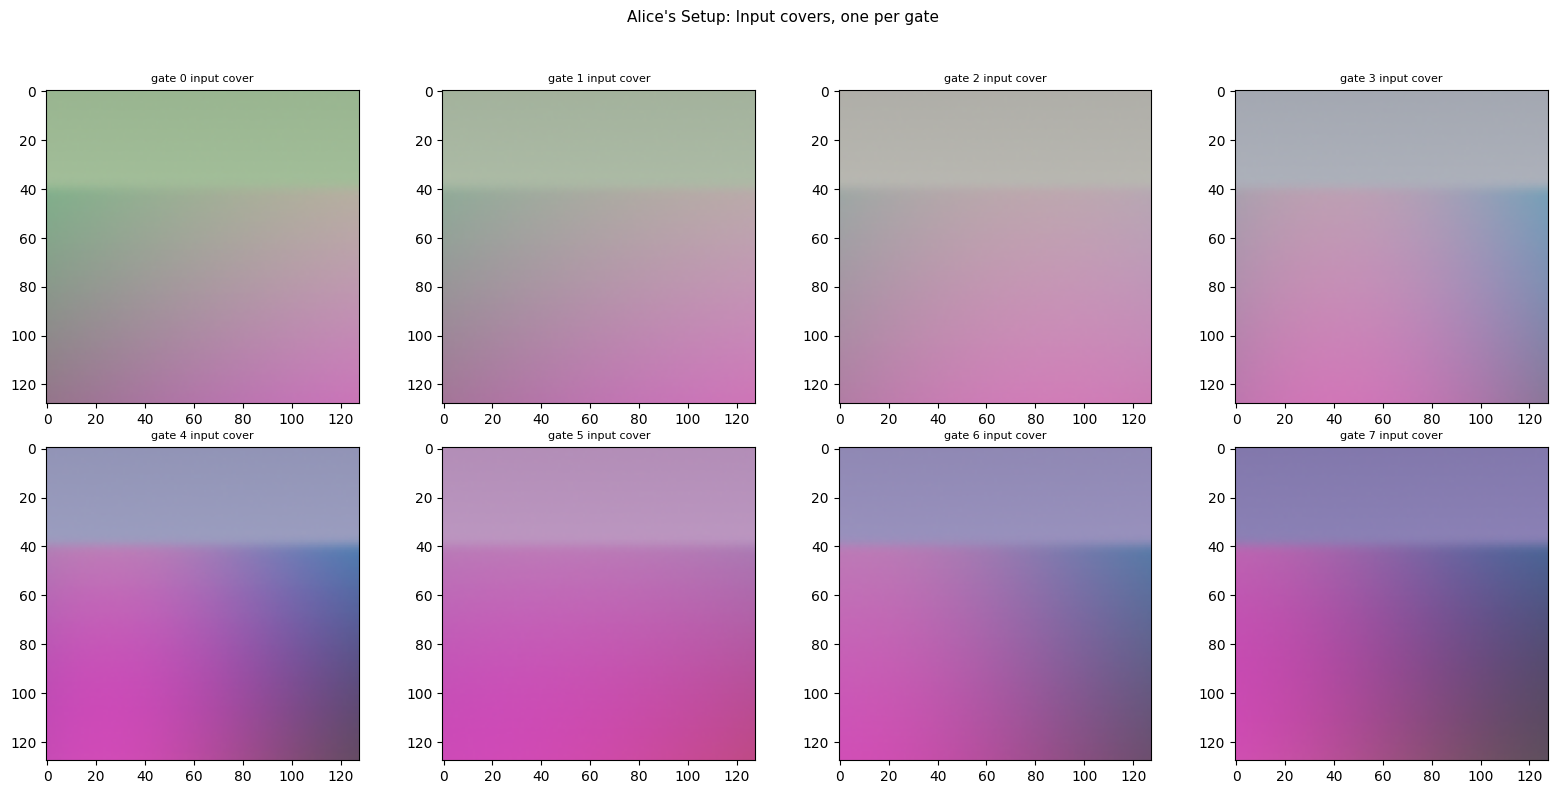

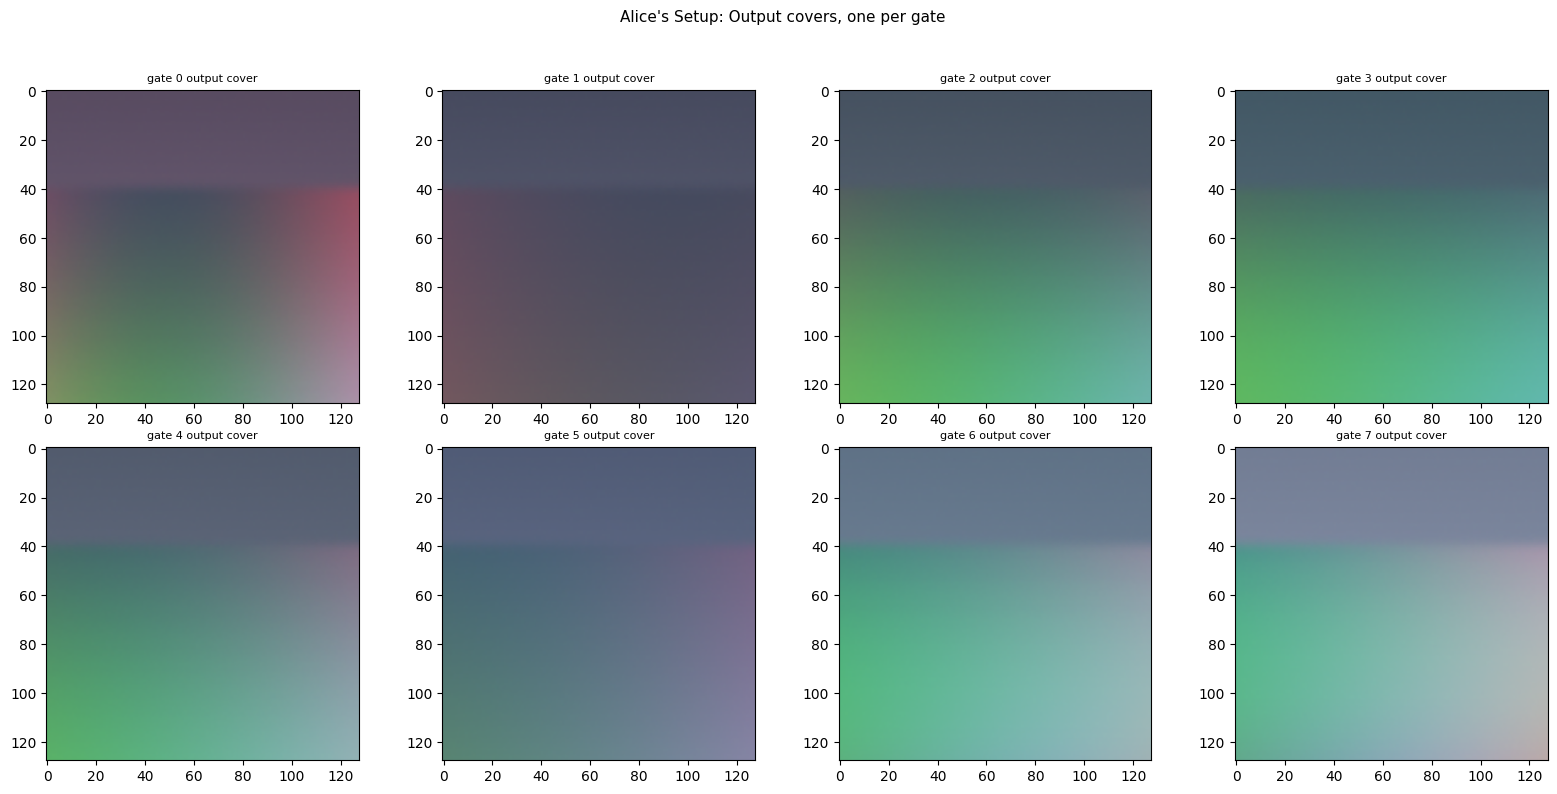

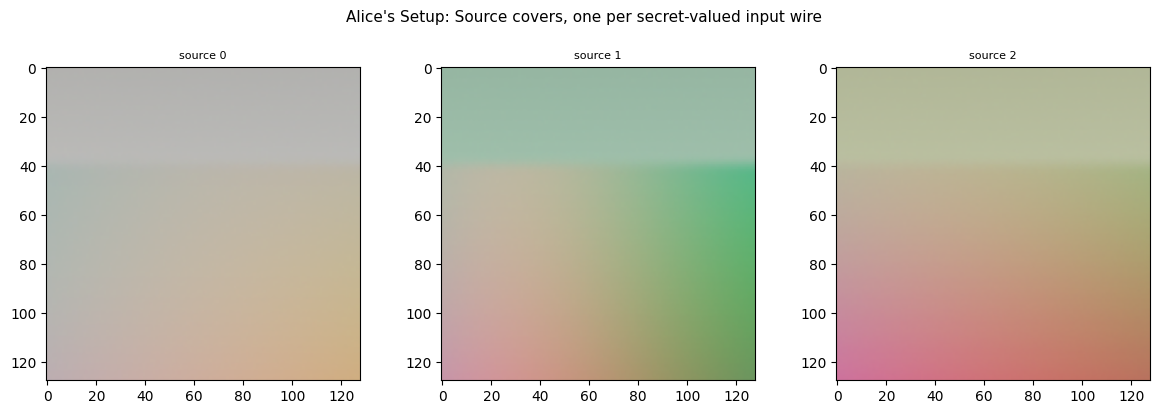

In [20]:
display_images({f"gate {i} input cover": img
                for i, img in enumerate(in_covers[:8])},
               title="Input covers, one per gate", stage="Alice's Setup",
               inline_display_enabled=SHOW_FIGURES)

display_images({f"gate {i} output cover": img
                for i, img in enumerate(out_covers[:8])},
               title="Output covers, one per gate", stage="Alice's Setup",
               inline_display_enabled=SHOW_FIGURES)

display_images({f"source {i}": img for i, img in enumerate(src_covers)},
               title="Source covers, one per secret-valued input wire",
               stage="Alice's Setup", inline_display_enabled=SHOW_FIGURES)

### Are these covers actually suitable?

The security analysis treats the decoy bits at every non-secret pixel as i.i.d. uniform. Whether an album satisfies that on its own depends entirely on the pictures, so measure rather than assume.

In [21]:
_ = cover_report(covers)

[COVERS] 31 image(s), channel 0 LSB plane
         fraction of set bits : 0.4993   (uniform = 0.5000)
         neighbour agreement  : 0.5004   (independent = 0.5000)
         worst single image   : 0.5098
         -> Already close to uniform i.i.d., so R1 costs you
            nothing here and removes the dependence on it.


To make the difference concrete, here is what the same measurement says about four kinds of cover. Neighbour agreement is how often horizontally adjacent LSBs match, which sits at 0.5 for an independent plane.

cover type                      set bits   nbr agree   after R1
----------------------------------------------------------------
flat / screenshot-like            0.5000      0.9921     0.4968
noiseless gradient                0.0000      1.0000     0.4980
heavily compressed JPEG           0.5000      0.9921     0.5017
your album, first image           0.5029      0.5007     0.5041


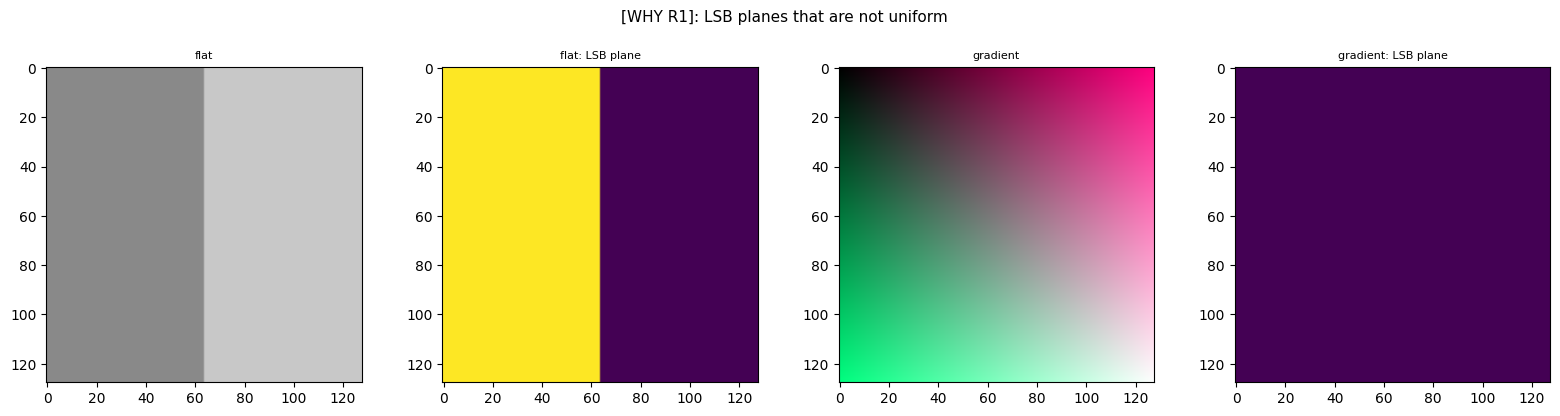

In [22]:
import io
from PIL import Image as _Image
H = W = 128
yy, xx = np.mgrid[0:H, 0:W]

flat = np.full((H, W, 3), 137, dtype=np.uint8); flat[:, 64:] = 200
ramp = np.stack([(xx * 2) % 256, (yy * 2) % 256, (xx + yy) % 256],
                -1).astype(np.uint8)
_buf = io.BytesIO()                      # in memory, no disk, no path issues
_Image.fromarray(flat).save(_buf, format="JPEG", quality=30)
_buf.seek(0)
jpeg = np.array(_Image.open(_buf).convert("RGB"))
noisy = covers[0]

print(f"{'cover type':<30} {'set bits':>9} {'nbr agree':>11} {'after R1':>10}")
print("-" * 64)
for name, img in [("flat / screenshot-like", flat),
                  ("noiseless gradient", ramp),
                  ("heavily compressed JPEG", jpeg),
                  ("your album, first image", noisy)]:
    a = lsb_plane_stats(img, 0)
    b = lsb_plane_stats(randomise_lsb_plane(img, 0), 0)
    print(f"{name:<30} {a['ones']:>9.4f} {a['neighbour_agree']:>11.4f} "
          f"{b['neighbour_agree']:>10.4f}")

display_images({"flat": flat, "flat: LSB plane": (flat[:, :, 0] & 1) * 255,
                "gradient": ramp, "gradient: LSB plane": (ramp[:, :, 0] & 1) * 255},
               title="LSB planes that are not uniform", stage="[WHY R1]",
               inline_display_enabled=SHOW_FIGURES)

The noiseless gradient is the clearest case: its LSB plane is entirely zero. Embed one secret bit into that and you get a single lit pixel on a black field, which no amount of positional analysis can rescue. R1 rewrites the plane first, so the album's own statistics stop mattering.

Noisy camera photographs are usually fine without it. R1 costs one pass over the image either way, which is why it is on by default rather than conditional.

### The protocol on your covers

In [23]:
out, timing = run_protocol(CIRCUIT_SPEC, {"A": 1, "B": 0, "C": 1},
                           image_shape=IMG_SHAPE,
                           cover_dir=active_dir,
                           verbose=False, seed=11)
print(f"result = {out['result']}, expected 1: "
      f"{'MATCH' if out['result'] == 1 else 'MISMATCH'}")
print(f"{timing['images_transmitted']} images transmitted, "
      f"{timing['constant_planes_local']} constant planes built by Carol")
print(f"compute {timing['compute_seconds']*1000:.1f} ms "
      f"({timing['per_gate_compute_seconds']*1000:.2f} ms/gate), "
      f"assemble {timing['assemble_seconds']*1000:.1f} ms, "
      f"comp {timing['comp_seconds']*1000:.1f} ms")

result = 1, expected 1: MATCH
31 images transmitted, 2 constant planes built by Carol
compute 8.3 ms (0.59 ms/gate), assemble 2.6 ms, comp 5.7 ms


## 6. A full verbose run

Every gate, every permutation, every wire carrier, with timing per step.

In [24]:
bits = {"A": 1, "B": 0, "C": 1}
expected = int((bits["A"] & bits["C"]) | ((1 - bits["A"]) & bits["B"])
               | ((1 - bits["B"]) & (1 - bits["C"])))
print(f"Expected f(A={bits['A']}, B={bits['B']}, C={bits['C']}) = {expected}\n")

out, timing = run_protocol(CIRCUIT_SPEC, bits, image_shape=IMG_SHAPE,
                           cover_dir=active_dir, verbose=True, seed=42)
print(f"\\nBob recovered result = {out['result']}, expected {expected}: "
      f"{'MATCH' if out['result'] == expected else 'MISMATCH'}")

Expected f(A=1, B=0, C=1) = 1


CRISP — protocol-faithful end-to-end execution
Alice -> Carol (no row,col) -> Bob

[SETUP] Circuit: 14 gates, 3 primary inputs, 2 ancillaries.
[SETUP] Image shape: (128, 128, 3)
[SETUP] Images transmitted: 31 = 2*14 (per-gate) + 3 (sources)
[SETUP] Plus 2 constant plane(s) Carol builds locally, never sent (R2)
[ALICE] Loaded 31 cover(s) from sample_covers
[ALICE] Shape (128, 128, 3), 16384 pixels each
         0: cover_000.png
         1: cover_001.png
         2: cover_002.png
         3: cover_003.png
         ... and 27 more
[LOCGEN] Secret position sampled: (28, 6)
[ALICE] 14 input cover(s), 14 output cover(s), 3 source cover(s)

[ALICE] Preparing 3 primary input(s) + 0 ancillary source image(s).
  [EMB] A = 1 at (28,6,0): pixel 185 -> 185  (plane re-randomised, R1)
  [EMB] B = 0 at (28,6,0): pixel 156 -> 156  (plane re-randomised, R1)
  [EMB] C = 1 at (28,6,0): pixel 185 -> 185  (plane re-randomised, R1)
  [R2] 2 constant wire(s) not transmitted; Ca

### Watching the images change, gate by gate

Same protocol on a three-gate slice, with the per-gate display hook switched on. Each row shows the assembled gate input and the gate output. They look like noise because they are: `comp` rewrites every pixel of all three channels, so the secret pixel has no visual signature.

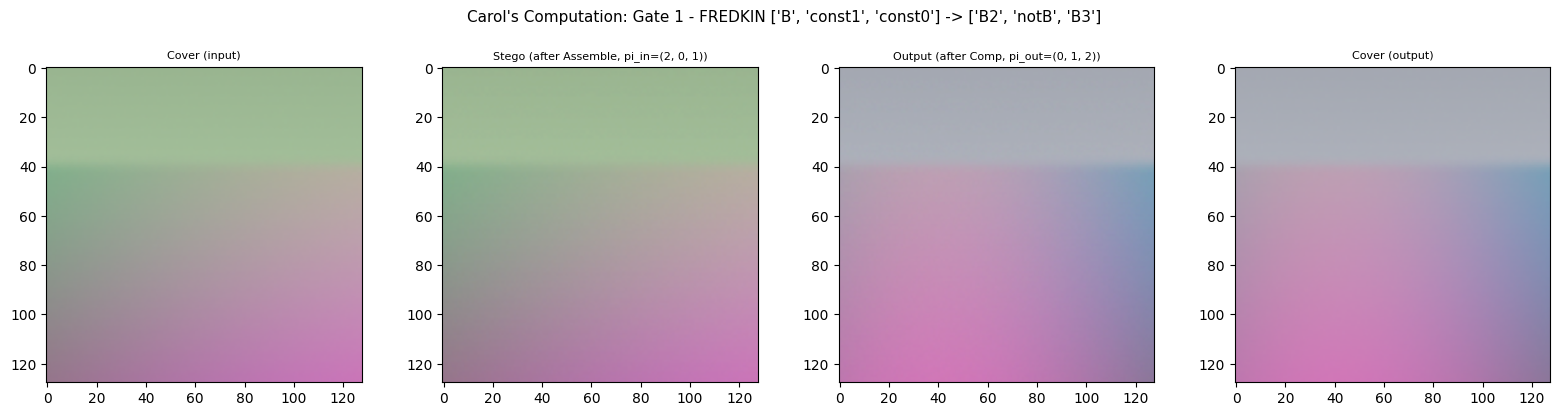

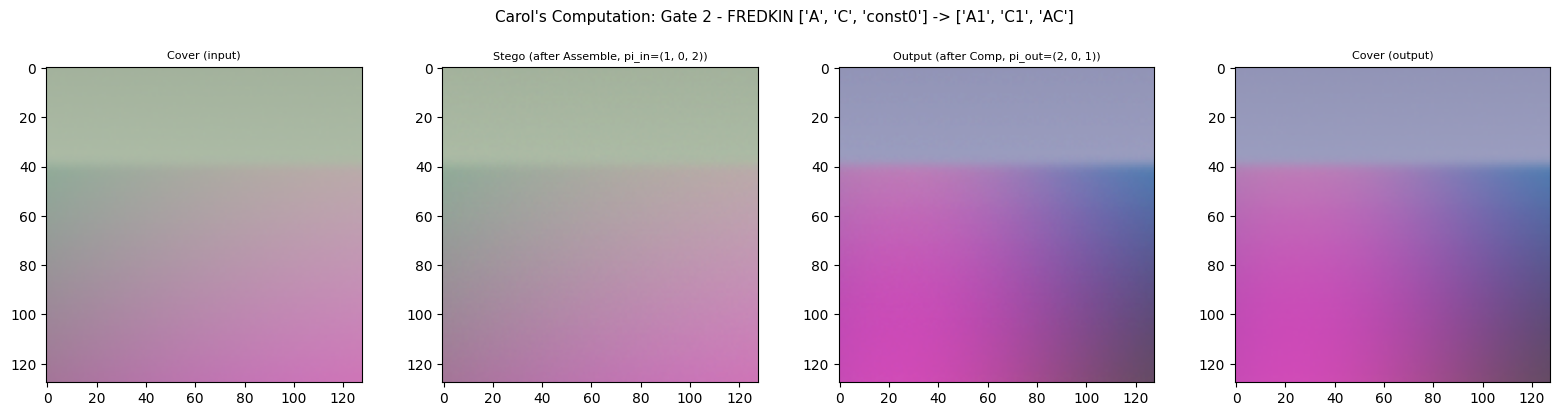

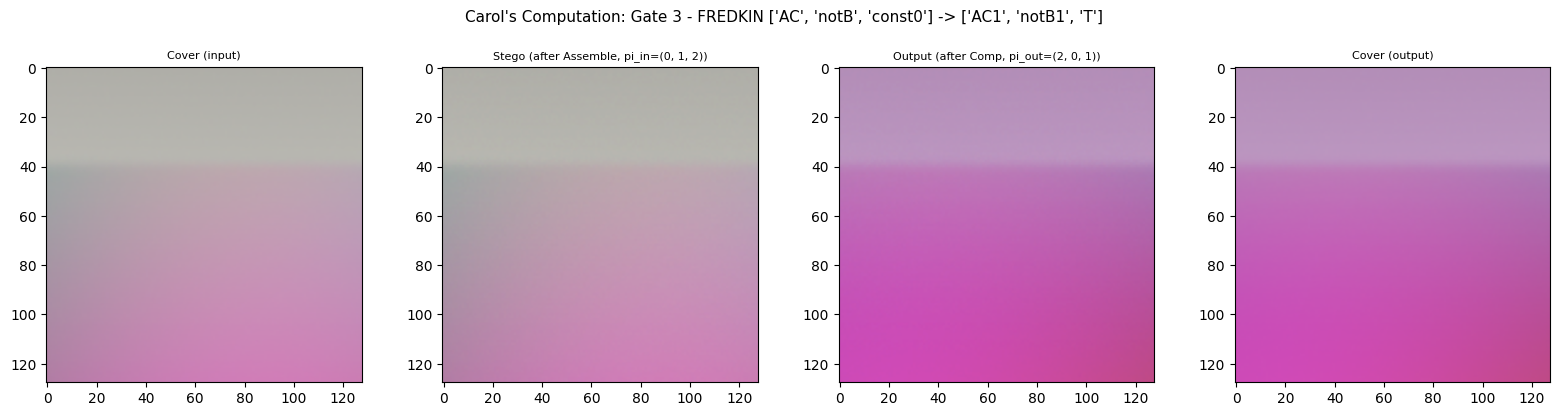

result T = 1  |  expected (A AND C) AND NOT B = 1
9 images sent, 2 constant planes built locally


In [25]:
SMALL_CIRCUIT = """
INPUT A, B, C
ANCILLARY const0 = 0
ANCILLARY const1 = 1
FREDKIN A, C, const0 -> A1, C1, AC
FREDKIN B, const1, const0 -> B2, notB, B3
FREDKIN AC, notB, const0 -> AC1, notB1, T
OUTPUT T
"""

out, timing = run_protocol(SMALL_CIRCUIT, {"A": 1, "B": 0, "C": 1},
                           image_shape=IMG_SHAPE, cover_dir=active_dir,
                           verbose=False, display_gates=True, seed=7)
print(f"result T = {out['T']}  |  expected (A AND C) AND NOT B = "
      f"{(1 & 1) & (1 - 0)}")
print(f"{timing['images_transmitted']} images sent, "
      f"{timing['constant_planes_local']} constant planes built locally")

## 7. Correctness

288 unit tests, being 8 input triples by 6 choices of `pi_in` by 6 of `pi_out`, each at a random secret position. Then the full truth table on the end-to-end pipeline.

In [26]:
def run_unit_tests(verbose: bool = False) -> bool:
    """Exhaustively verify the Emb -> Assemble -> Comp -> Ext pipeline.

    For every (c, x, y) input triple and every (pi_in, pi_out) permutation
    pair, the pipeline must recover the correct Fredkin output.
    """
    print("=" * 64)
    print("UNIT TESTS  (288 = 8 input triples * 6 pi_in * 6 pi_out)")
    print("=" * 64)

    h, w = 16, 16
    src1 = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)
    src2 = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)
    src3 = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)
    in_cover = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)
    out_cover = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)

    passed = 0
    failed = 0
    failures: List[str] = []

    for c, x, y in itertools.product([0, 1], repeat=3):
        expected = fredkin(c, x, y)
        for pi_in in ALL_PERMS:
            for pi_out in ALL_PERMS:
                row = random.randrange(h)
                col = random.randrange(w)

                # Each input bit lives in a separate source image,
                # at channel 0 of (row, col). This is exactly the
                # protocol-faithful path.
                a = emb_bit(src1, c, row, col, 0)
                b = emb_bit(src2, x, row, col, 0)
                d = emb_bit(src3, y, row, col, 0)
                wire_sources_list = [(a, 0), (b, 0), (d, 0)]

                stego = assemble_stego(
                    in_cover, wire_sources_list, pi_in)
                out_img = comp(stego, out_cover, pi_in, pi_out)
                got = (
                    ext_bit(out_img, row, col, pi_out[0]),
                    ext_bit(out_img, row, col, pi_out[1]),
                    ext_bit(out_img, row, col, pi_out[2]),
                )
                if got == expected:
                    passed += 1
                    if verbose:
                        print(f"  PASS ({c},{x},{y}) pi_in={pi_in} "
                              f"pi_out={pi_out} -> {got}")
                else:
                    failed += 1
                    failures.append(
                        f"  FAIL ({c},{x},{y}) pi_in={pi_in} "
                        f"pi_out={pi_out} expected={expected} got={got}")

    print(f"\n  Passed : {passed}/288")
    print(f"  Failed : {failed}/288")
    for msg in failures[:5]:
        print(msg)
    if failed > 5:
        print(f"  ... and {failed - 5} more failures.")
    ok = (failed == 0)
    print(f"\n  Result : {'ALL 288 TESTS PASSED' if ok else 'SOME TESTS FAILED'}")
    return ok

In [27]:
ok_units = run_unit_tests(verbose=False)

UNIT TESTS  (288 = 8 input triples * 6 pi_in * 6 pi_out)

  Passed : 288/288
  Failed : 0/288

  Result : ALL 288 TESTS PASSED


In [28]:
def run_truth_table(circuit_spec: str,
                    image_shape: Tuple[int, int, int] = (64, 64, 3),
                    verbose: bool = True) -> bool:
    """Verify the 8 truth-table rows for the benchmark function.

    The benchmark is f(A, B, C) = (A AND C) OR (NOT A AND B) OR (NOT B AND NOT C).
    """
    print("\n" + "=" * 64)
    print("TRUTH TABLE — (A AND C) OR (NOT A AND B) OR (NOT B AND NOT C)")
    print("=" * 64)

    circuit = parse_circuit(circuit_spec)
    if len(circuit.outputs) != 1:
        raise ValueError("Truth-table verifier expects exactly 1 output.")
    if len(circuit.inputs) != 3:
        raise ValueError("Truth-table verifier expects exactly 3 inputs.")

    out_wire = circuit.outputs[0]
    in_names = circuit.inputs
    all_ok = True

    print(f"\n  {'A':>3}  {'B':>3}  {'C':>3}  "
          f"{'Expected':>10}  {'CRISP':>7}  {'OK':>4}")
    print("  " + "-" * 42)
    for A, B, C in itertools.product([0, 1], repeat=3):
        expected = int((A & C) | ((1 - A) & B) | ((1 - B) & (1 - C)))
        bits = {in_names[0]: A, in_names[1]: B, in_names[2]: C}
        out, _ = run_protocol(circuit_spec, bits,
                              image_shape=image_shape, verbose=False)
        got = out[out_wire]
        ok = (got == expected)
        all_ok = all_ok and ok
        print(f"  {A:>3}  {B:>3}  {C:>3}  {expected:>10}  {got:>7}  "
              f"{'OK' if ok else 'FAIL':>4}")
    print(f"\n  Result: {'ALL 8 CASES CORRECT' if all_ok else 'SOME FAILURES'}")
    return all_ok

In [29]:
ok_truth = run_truth_table(CIRCUIT_SPEC, image_shape=(64, 64, 3), verbose=True)
print()
print("CORRECTNESS:", "PASS" if ok_units and ok_truth else "FAIL")


TRUTH TABLE — (A AND C) OR (NOT A AND B) OR (NOT B AND NOT C)

    A    B    C    Expected    CRISP    OK
  ------------------------------------------


    0    0    0           1        1    OK
    0    0    1           0        0    OK


    0    1    0           1        1    OK


    0    1    1           1        1    OK
    1    0    0           1        1    OK


    1    0    1           1        1    OK
    1    1    0           0        0    OK


    1    1    1           1        1    OK

  Result: ALL 8 CASES CORRECT

CORRECTNESS: PASS


## 8. Looking at the images

This is the point of the whole construction, so it uses your covers rather than generated ones. A stego image differs from its cover in one bit of one pixel. Nothing about it looks different, and the gate outputs still look like ordinary pictures even though Carol has rewritten the low bit of all three channels at every pixel.

The LSB planes are where the change lives. Amplify them and you see the cover's own plane, then the uniform field R1 leaves behind, then the gate output. None of them marks the secret pixel.

[LOCGEN] Secret position sampled: (60, 31)


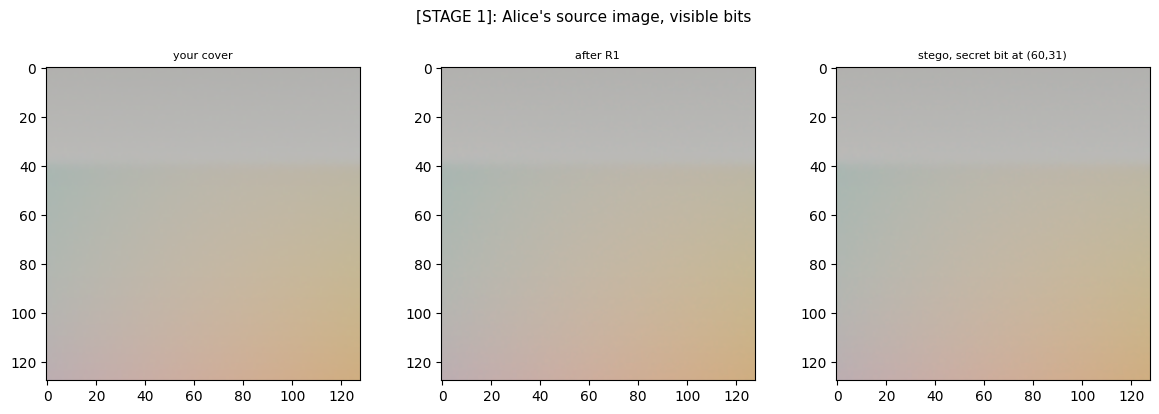

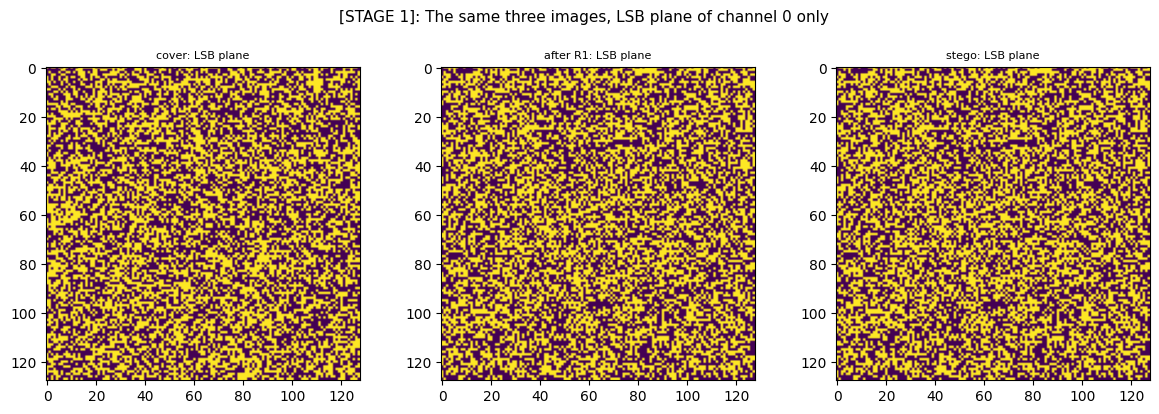

cover -> stego, largest change to any sample: 1
R1 rewrote 8185 of 16384 LSBs; Alice then changed exactly one more.

cover   LSB plane: {'ones': 0.4932861328125, 'neighbour_agree': 0.5098425196850394, 'excess_over_uniform': 0.009842519685039353}
after R1 LSB plane: {'ones': 0.49359130859375, 'neighbour_agree': 0.49673966535433073, 'excess_over_uniform': 0.0032603346456692717}


In [30]:
cover = src_covers[0]            # one of your own covers
shape = cover.shape
row, col = locgen(shape, interactive=False)
rerand = randomise_lsb_plane(cover, 0)
stego = emb_bit(rerand, 1, row, col, 0)

display_images({"your cover": cover,
                "after R1": rerand,
                f"stego, secret bit at ({row},{col})": stego},
               title="Alice's source image, visible bits",
               stage="[STAGE 1]", inline_display_enabled=SHOW_FIGURES)

display_images({"cover: LSB plane": (cover[:, :, 0] & 1) * 255,
                "after R1: LSB plane": (rerand[:, :, 0] & 1) * 255,
                "stego: LSB plane": (stego[:, :, 0] & 1) * 255},
               title="The same three images, LSB plane of channel 0 only",
               stage="[STAGE 1]", inline_display_enabled=SHOW_FIGURES)

n_pix = shape[0] * shape[1]
print(f"cover -> stego, largest change to any sample: "
      f"{int(np.abs(cover.astype(int) - stego.astype(int)).max())}")
print(f"R1 rewrote {int(((cover[:,:,0] & 1) != (rerand[:,:,0] & 1)).sum())} "
      f"of {n_pix} LSBs; Alice then changed exactly one more.")
print()
print("cover   LSB plane:", lsb_plane_stats(cover, 0))
print("after R1 LSB plane:", lsb_plane_stats(rerand, 0))

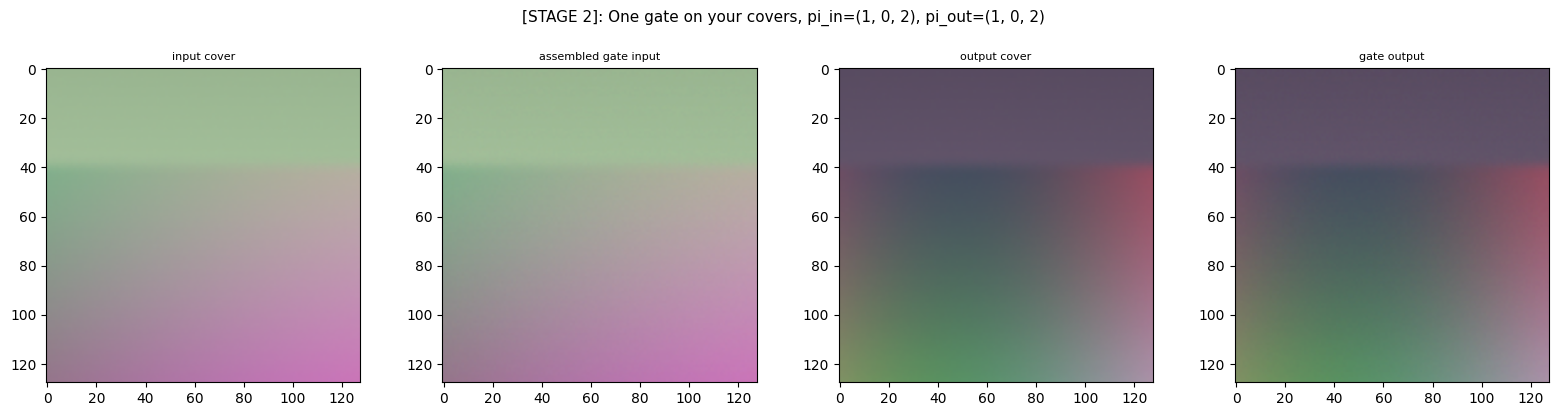

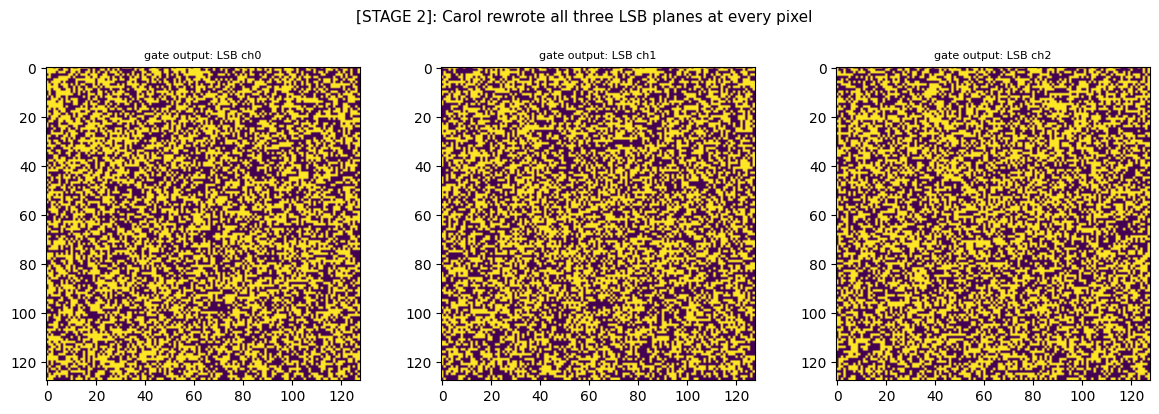

pi_in = (1, 0, 2)   pi_out = (1, 0, 2)
output vs its cover, largest change to any sample: 1
Carol rewrote the low bit of all three channels at all 16384 pixels, and the picture is unchanged to the eye.


In [31]:
in_cover, out_cover = in_covers[0], out_covers[0]
pi_in, pi_out = perm_gen()
src = [(stego, 0),
       (emb_bit(randomise_lsb_plane(src_covers[1], 0), 0, row, col, 0), 0),
       (emb_bit(randomise_lsb_plane(src_covers[2], 0), 1, row, col, 0), 0)]
asm = assemble_stego(in_cover, src, pi_in)
res = comp(asm, out_cover, pi_in, pi_out)

display_images({"input cover": in_cover,
                "assembled gate input": asm,
                "output cover": out_cover,
                "gate output": res},
               title=f"One gate on your covers, pi_in={pi_in}, pi_out={pi_out}",
               stage="[STAGE 2]", inline_display_enabled=SHOW_FIGURES)

display_images({"gate output: LSB ch0": (res[:, :, 0] & 1) * 255,
                "gate output: LSB ch1": (res[:, :, 1] & 1) * 255,
                "gate output: LSB ch2": (res[:, :, 2] & 1) * 255},
               title="Carol rewrote all three LSB planes at every pixel",
               stage="[STAGE 2]", inline_display_enabled=SHOW_FIGURES)

print(f"pi_in = {pi_in}   pi_out = {pi_out}")
print(f"output vs its cover, largest change to any sample: "
      f"{int(np.abs(out_cover.astype(int) - res.astype(int)).max())}")
print(f"Carol rewrote the low bit of all three channels at all "
      f"{shape[0] * shape[1]} pixels, and the picture is unchanged to the eye.")

## 9. Positional security, and the attack

Carol's optimal joint recovery of the secret pixel and the secret input satisfies

$$\mathrm{Adv}^{\mathsf{joint}} \;=\; \mathbb{E}\!\left[\tfrac{1}{1+B}\right] \;\ge\; \frac{2^{\lambda}}{2^{\lambda}+n-1}, \qquad B \sim \mathrm{Bin}(n-1,\,2^{-\lambda})$$

with $n = h \times w$ and $\lambda = m - H_2(q)$, the gap between the number of secret input bits and the collision entropy of Carol's prior on them. $\lambda$ counts the bits she already knows, and each one halves the candidate pixel set. At $\lambda = 0$ this is exactly $1/n$.

Public-constant wires are the practical source of $\lambda > 0$. The attack below constant-propagates the specification, then filters candidate pixels on every wire whose value it derives.

In [32]:
def known_constant_wires(circuit: Circuit) -> Dict[str, int]:
    """Every wire whose value follows from the public specification alone.

    Starts at the constant ancillaries and propagates forward through any
    gate all of whose inputs are already known.
    """
    known = {w: v for w, v in circuit.ancillaries}
    changed = True
    while changed:
        changed = False
        for gate in circuit.gates:
            ci, xi, yi = gate["inputs"]
            co, xo, yo = gate["outputs"]
            if all(w in known for w in (ci, xi, yi)) and co not in known:
                a, b, c = fredkin(known[ci], known[xi], known[yi])
                known[co], known[xo], known[yo] = a, b, c
                changed = True
    return known


def attack_full_transcript(view: Dict, verbose: bool = False) -> Dict:
    """Carol filters candidate pixels using every value she can derive.

    She holds the circuit specification, so she knows each ancillary's
    constant and can propagate it forward.  For each such wire she keeps
    only pixels whose LSB agrees with the value she expects.  The secret
    pixel always survives, so the survivors are her candidate set and her
    optimal move is to guess uniformly among them.

    Under R2 the constant planes are pixel-uniform, nothing is filtered,
    and the candidate set is the whole image.
    """
    circuit = view["circuit"]
    h, w, _ = view["image_shape"]
    row, col = view["secret"]
    wires = view["wire_map"]

    known = known_constant_wires(circuit)
    candidates = np.ones((h, w), dtype=bool)
    used = 0
    for wire, value in known.items():
        if wire not in wires:
            continue
        img, ch = wires[wire]
        plane = (img[:, :, ch] & 1) == value
        if plane.all():
            continue                      # pixel-uniform: filters nothing
        before = int(candidates.sum())
        candidates &= plane
        used += 1
        if verbose:
            print(f"  [ATTACK] filter on {wire}={value}: "
                  f"{before} -> {int(candidates.sum())} candidates")

    n_cand = int(candidates.sum())
    return {"derivable_wires": len(known), "filters_applied": used,
            "candidates": n_cand, "secret_survives": bool(candidates[row, col]),
            "adv": 1.0 / n_cand, "degradation": (h * w) / n_cand,
            "pinned": n_cand == 1}

In [33]:
def nb_attack_demo(image_size: int = 128):
    """Show the filter shrinking the candidate set, wire by wire."""
    print("R2 OFF - constants embedded only at the secret pixel")
    out, t, view = run_protocol(CIRCUIT_SPEC, {"A": 1, "B": 0, "C": 1},
                                image_shape=(image_size, image_size, 3),
                                verbose=False, apply_r2=False,
                                return_view=True)
    a = attack_full_transcript(view, verbose=True)
    print(f"  -> {a['candidates']} candidates of {image_size**2}, "
          f"advantage {a['adv']:.3e} ({a['degradation']:.1f}x worse than 1/n)")
    print(f"  -> secret pixel survived: {a['secret_survives']}")

    print("\nR2 ON - constants are pixel-uniform planes Carol builds")
    out, t, view = run_protocol(CIRCUIT_SPEC, {"A": 1, "B": 0, "C": 1},
                                image_shape=(image_size, image_size, 3),
                                verbose=False, apply_r2=True,
                                return_view=True)
    b = attack_full_transcript(view, verbose=True)
    print(f"  -> {b['candidates']} candidates of {image_size**2}, "
          f"advantage {b['adv']:.3e} ({b['degradation']:.1f}x worse than 1/n)")
    print(f"  -> {b['derivable_wires']} wires were derivable; "
          f"{b['filters_applied']} filters had any effect")
    return a, b


_ = nb_attack_demo(image_size=128)

R2 OFF - constants embedded only at the secret pixel
  [ATTACK] filter on const0=0: 16384 -> 8129 candidates
  [ATTACK] filter on const1=1: 8129 -> 4114 candidates
  -> 4114 candidates of 16384, advantage 2.431e-04 (4.0x worse than 1/n)
  -> secret pixel survived: True

R2 ON - constants are pixel-uniform planes Carol builds


  -> 16384 candidates of 16384, advantage 6.104e-05 (1.0x worse than 1/n)
  -> 2 wires were derivable; 0 filters had any effect


The two filters above are `const0` and `const1`, the benchmark's only constant wires, so $\kappa = 2$ and the candidate set shrinks about fourfold. With R2 on both planes are pixel-uniform, every pixel passes, and the set is the whole image.

One subtlety worth stating: wires whose values follow from the constants by propagation add nothing further. Any pixel that already survives the filters on a gate's constant inputs reproduces that gate's outputs automatically, so those constraints are implied rather than independent. Only the count of **distinct constant carriers** matters, which is why `derivable_wires` exceeds `filters_applied` above.

## 10. Benchmarks

In [34]:
def bench_per_gate_timing(image_sizes: Tuple[int, ...] = (64, 128, 256, 512),
                          n_trials: int = 20) -> List[Tuple]:
    """Per-gate timing breakdown: Assemble vs Comp at multiple image sizes."""
    print("\n" + "=" * 72)
    print("BENCHMARK 1 — Per-gate timing breakdown (Assemble vs Comp)")
    print("=" * 72)
    print(f"{'Image':>10}  {'Pixels':>10}  "
          f"{'Assemble (ms)':>16}  {'Comp (ms)':>14}  {'Total (ms)':>14}")
    print("-" * 72)

    rows = []
    for s in image_sizes:
        shape = (s, s, 3)
        n_pix = s * s
        as_times, cp_times = [], []
        for _ in range(n_trials):
            cover = np.random.randint(0, 256, shape, dtype=np.uint8)
            a = np.random.randint(0, 256, shape, dtype=np.uint8)
            b = np.random.randint(0, 256, shape, dtype=np.uint8)
            d = np.random.randint(0, 256, shape, dtype=np.uint8)
            out_cover = np.random.randint(0, 256, shape, dtype=np.uint8)
            pi_in, pi_out = perm_gen()
            t0 = time.perf_counter()
            stego = assemble_stego(cover, [(a, 0), (b, 0), (d, 0)], pi_in)
            t1 = time.perf_counter()
            _ = comp(stego, out_cover, pi_in, pi_out)
            t2 = time.perf_counter()
            as_times.append(t1 - t0)
            cp_times.append(t2 - t1)
        a_mean = 1000 * float(np.mean(as_times))
        c_mean = 1000 * float(np.mean(cp_times))
        a_std = 1000 * float(np.std(as_times))
        c_std = 1000 * float(np.std(cp_times))
        total = a_mean + c_mean
        print(f"{s}x{s:<6} {n_pix:>10}  "
              f"{a_mean:>8.2f} +/- {a_std:<5.2f}  "
              f"{c_mean:>8.2f} +/- {c_std:<5.2f}  "
              f"{total:>10.2f}")
        rows.append((s, n_pix, a_mean, a_std, c_mean, c_std, total))
    return rows

In [35]:
_ = bench_per_gate_timing(image_sizes=(64, 128, 256), n_trials=20)


BENCHMARK 1 — Per-gate timing breakdown (Assemble vs Comp)
     Image      Pixels     Assemble (ms)       Comp (ms)      Total (ms)
------------------------------------------------------------------------
64x64           4096      0.09 +/- 0.02       0.22 +/- 0.39         0.31
128x128         16384      0.16 +/- 0.04       0.36 +/- 0.06         0.52
256x256         65536      0.59 +/- 0.09       1.37 +/- 0.15         1.96


In [36]:
def _make_linear_chain(n_gates: int) -> str:
    """Generate a linear-chain Fredkin circuit specification with n_gates."""
    lines = ["INPUT A, B, C",
             "ANCILLARY const0 = 0",
             "ANCILLARY const1 = 1"]
    cur = ["A", "B", "C"]
    for i in range(n_gates):
        outs = [f"w{i}_{j}" for j in range(3)]
        lines.append(f"FREDKIN {', '.join(cur)} -> {', '.join(outs)}")
        cur = outs
    lines.append(f"OUTPUT {cur[0]}")
    return "\n".join(lines)


def bench_image_count() -> List[Tuple]:
    """Compare ProSt's per-wire image count with CRISP's per-gate count."""
    print("\n" + "=" * 72)
    print("BENCHMARK 2 — Image count: CRISP vs ProSt across circuits")
    print("=" * 72)
    print(f"{'Circuit':>22}  {'Gates':>6}  {'Wires':>6}  "
          f"{'ProSt':>6}  {'CRISP':>6}  {'Reduction':>10}")
    print("-" * 72)

    circuits = [
        ("Benchmark, 14 gates", CIRCUIT_SPEC),
        ("Linear, 17 gates", _make_linear_chain(17)),
        ("Linear, 50 gates", _make_linear_chain(50)),
        ("Linear, 100 gates", _make_linear_chain(100)),
    ]

    rows = []
    for name, spec in circuits:
        circ = parse_circuit(spec)
        n = len(circ.gates)
        wires = len(get_all_wires(spec))
        n_src = len(circ.inputs) + len(circ.ancillaries)
        crisp = 2 * n + n_src
        reduction = wires / crisp
        print(f"{name:>22}  {n:>6}  {wires:>6}  "
              f"{wires:>6}  {crisp:>6}  {reduction:>9.2f}x")
        rows.append((name, n, wires, wires, crisp, reduction))
    return rows

In [37]:
_ = bench_image_count()


BENCHMARK 2 — Image count: CRISP vs ProSt across circuits
               Circuit   Gates   Wires   ProSt   CRISP   Reduction
------------------------------------------------------------------------
   Benchmark, 14 gates      14      47      47      33       1.42x
      Linear, 17 gates      17      56      56      39       1.44x
      Linear, 50 gates      50     155     155     105       1.48x
     Linear, 100 gates     100     305     305     205       1.49x


In [38]:
def bench_chi_square_steganalysis(image_sizes: Tuple[int, ...] = (64, 128, 256),
                                  n_trials: int = 200) -> List[Tuple]:
    """Empirical chi-square steganalysis of CRISP outputs vs natural covers.

    Tests the structural argument of Section 6.7 of the paper: because
    Comp processes every pixel uniformly, the LSB plane of a CRISP
    output should be statistically indistinguishable from a fresh
    natural cover.
    """
    print("\n" + "=" * 72)
    print("BENCHMARK 3 — Chi-square steganalysis on the LSB plane")
    print("=" * 72)
    print(f"{'Image':>10}  {'Natural mean':>15}  "
          f"{'CRISP mean':>15}  {'p(detect) at 0.05':>20}")
    print("-" * 72)

    rows = []
    crit = 3.841  # chi-square critical value at alpha=0.05, df=1
    for s in image_sizes:
        shape = (s, s, 3)
        n_total = 3 * s * s
        nat_chi, crisp_chi = [], []
        for _ in range(n_trials):
            # Natural cover (control).
            nat = np.random.randint(0, 256, shape, dtype=np.uint8)
            n0 = int(np.sum((nat & 1) == 0))
            n1 = n_total - n0
            exp = n_total / 2
            chi_nat = ((n0 - exp) ** 2 + (n1 - exp) ** 2) / exp
            nat_chi.append(chi_nat)

            # CRISP output.
            cover = np.random.randint(0, 256, shape, dtype=np.uint8)
            a = np.random.randint(0, 256, shape, dtype=np.uint8)
            b = np.random.randint(0, 256, shape, dtype=np.uint8)
            d = np.random.randint(0, 256, shape, dtype=np.uint8)
            out_cover = np.random.randint(0, 256, shape, dtype=np.uint8)
            pi_in, pi_out = perm_gen()
            stego = assemble_stego(cover, [(a, 0), (b, 0), (d, 0)], pi_in)
            out_img = comp(stego, out_cover, pi_in, pi_out)
            n0c = int(np.sum((out_img & 1) == 0))
            n1c = n_total - n0c
            chi_crisp = ((n0c - exp) ** 2 + (n1c - exp) ** 2) / exp
            crisp_chi.append(chi_crisp)

        nat_arr = np.array(nat_chi)
        crisp_arr = np.array(crisp_chi)
        nat_det = float(np.mean(nat_arr > crit))
        crisp_det = float(np.mean(crisp_arr > crit))
        print(f"{s}x{s:<6}  "
              f"{float(np.mean(nat_arr)):>14.3f}  "
              f"{float(np.mean(crisp_arr)):>14.3f}  "
              f"{crisp_det:.3f} (vs nat {nat_det:.3f})")
        rows.append((s, float(np.mean(nat_arr)), float(np.mean(crisp_arr)),
                     nat_det, crisp_det))

    print()
    print("Interpretation: CRISP outputs are statistically indistinguishable")
    print("from fresh natural covers under chi-square detection. False-")
    print("positive rates land near the nominal 5% baseline for both.")
    return rows

In [39]:
_ = bench_chi_square_steganalysis(image_sizes=(64, 128), n_trials=100)


BENCHMARK 3 — Chi-square steganalysis on the LSB plane
     Image     Natural mean       CRISP mean     p(detect) at 0.05
------------------------------------------------------------------------


64x64               1.156           0.925  0.040 (vs nat 0.040)


128x128              1.303           1.047  0.060 (vs nat 0.080)



Interpretation: CRISP outputs are statistically indistinguishable
from fresh natural covers under chi-square detection. False-
positive rates land near the nominal 5% baseline for both.


In [40]:
def bench_security_empirical(
        image_sizes: Tuple[Tuple[int, int], ...] = (
            (8, 8), (16, 16), (32, 32), (64, 64), (128, 128)),
        n_trials: int = 10000) -> List[Tuple]:
    """Joint position-and-value recovery when lambda = 0."""
    print("\n" + "=" * 72)
    print("BENCHMARK 4 - Joint position+value recovery at lambda = 0")
    print("=" * 72)
    print("With repairs R1 and R2 in place, Carol knows nothing about the")
    print("secret input beyond its prior, so her posterior over pixels stays")
    print("uniform.  Her optimal strategy is to pick a pixel at random and")
    print("read its three LSBs, winning at rate 1/n.  bench_constant_leak()")
    print("measures what happens when lambda > 0.")
    print()
    print(f"{'Image':>10}  {'n=h*w':>8}  {'1/n':>14}  "
          f"{'Empirical':>14}  {'|delta|':>10}")
    print("-" * 72)

    rows = []
    for h, w in image_sizes:
        n = h * w
        wins = 0
        for _ in range(n_trials):
            r_s, c_s = random.randrange(h), random.randrange(w)
            t_s = (random.randrange(2),
                   random.randrange(2),
                   random.randrange(2))
            img_lsb = np.random.randint(0, 2, (h, w, 3), dtype=np.uint8)
            img_lsb[r_s, c_s, :] = t_s
            r_g, c_g = random.randrange(h), random.randrange(w)
            t_g = tuple(int(img_lsb[r_g, c_g, k]) for k in range(3))
            if (r_g, c_g) == (r_s, c_s) and t_g == t_s:
                wins += 1
        empirical = wins / n_trials
        theor = 1.0 / n
        delta = abs(empirical - theor)
        print(f"{h}x{w:<6}  {n:>8}  "
              f"{theor:>13.6e}  {empirical:>13.6e}  {delta:>9.2e}")
        rows.append((h, w, theor, empirical, delta))

    print()
    print("All empirical rates match 1/n within sampling error.  This is the")
    print("lambda = 0 case only; every bit of the secret input that Carol")
    print("already knows halves her candidate set.")
    return rows

In [41]:
_ = bench_security_empirical(
        image_sizes=((8, 8), (16, 16), (32, 32), (64, 64)), n_trials=4000)


BENCHMARK 4 - Joint position+value recovery at lambda = 0
With repairs R1 and R2 in place, Carol knows nothing about the
secret input beyond its prior, so her posterior over pixels stays
uniform.  Her optimal strategy is to pick a pixel at random and
read its three LSBs, winning at rate 1/n.  bench_constant_leak()
measures what happens when lambda > 0.

     Image     n=h*w             1/n       Empirical     |delta|
------------------------------------------------------------------------


8x8             64   1.562500e-02   1.575000e-02   1.25e-04
16x16           256   3.906250e-03   3.250000e-03   6.56e-04


32x32          1024   9.765625e-04   7.500000e-04   2.27e-04


64x64          4096   2.441406e-04   2.500000e-04   5.86e-06

All empirical rates match 1/n within sampling error.  This is the
lambda = 0 case only; every bit of the secret input that Carol
already knows halves her candidate set.


In [42]:
def bench_constant_leak(image_shape=(128, 128, 3), n_trials: int = 40):
    """BENCHMARK 6 - what constant wires cost, measured on real transcripts."""
    n = image_shape[0] * image_shape[1]
    print("\n" + "=" * 72)
    print("BENCHMARK 6 - Constant-wire leak, with R2 off and on")
    print("=" * 72)
    print(f"{'R2':>5}  {'filters':>8}  {'images':>7}  {'mean cands':>11}  "
          f"{'advantage':>12}  {'vs 1/n':>9}")
    print("-" * 72)
    rows = []
    for r2 in (False, True):
        cands, advs, filt, ok = [], [], 0, True
        for _ in range(n_trials):
            out, timing, view = run_protocol(
                CIRCUIT_SPEC, {"A": 1, "B": 0, "C": 1},
                image_shape=image_shape, verbose=False,
                apply_r2=r2, return_view=True)
            a = attack_full_transcript(view)
            ok &= a["secret_survives"]
            cands.append(a["candidates"]); advs.append(a["adv"])
            filt = a["filters_applied"]
        mean_adv = sum(advs) / n_trials
        mean_cand = sum(cands) / n_trials
        print(f"{'on' if r2 else 'off':>5}  {filt:>8}  "
              f"{timing['images_transmitted']:>7}  {mean_cand:>11.1f}  "
              f"{mean_adv:>12.3e}  {mean_adv * n:>8.1f}x")
        rows.append((r2, filt, mean_cand, mean_adv))
        assert ok, "the secret pixel must always survive Carol's own filter"
    print()
    print("R2 restores exactly 1/n and sends two fewer images.")
    return rows


def bench_lambda_sweep(n: int = 128 * 128,
                       kappas=(0, 1, 3, 5, 7, 10, 14),
                       trials: int = 2_000_000):
    """BENCHMARK 7 - the bound itself, swept over the number of known bits."""
    rng = np.random.default_rng(7)
    print("\n" + "=" * 72)
    print(f"BENCHMARK 7 - Bound vs lambda   (n = {n})")
    print("=" * 72)
    print(f"{'lambda':>7}  {'measured':>13}  {'2^k/(2^k+n-1)':>15}  {'vs 1/n':>9}")
    print("-" * 72)
    rows = []
    for k in kappas:
        B = rng.binomial(n - 1, 2.0 ** (-k), size=trials)
        meas = float(np.mean(1.0 / (1.0 + B)))
        bound = (2.0 ** k) / (2.0 ** k + n - 1)
        print(f"{k:>7}  {meas:>13.3e}  {bound:>15.3e}  {meas * n:>8.1f}x")
        rows.append((k, meas, bound))
    print()
    print("Each known bit halves the candidate set.  Wires whose values follow")
    print("from the constants by propagation add nothing further: any pixel")
    print("surviving the filters on a gate's inputs reproduces its outputs.")
    return rows

In [43]:
_ = bench_constant_leak(image_shape=(128, 128, 3), n_trials=30)


BENCHMARK 6 - Constant-wire leak, with R2 off and on
   R2   filters   images   mean cands     advantage     vs 1/n
------------------------------------------------------------------------


  off         2       33       4100.8     2.439e-04       4.0x


   on         0       31      16384.0     6.104e-05       1.0x

R2 restores exactly 1/n and sends two fewer images.


In [44]:
_ = bench_lambda_sweep()


BENCHMARK 7 - Bound vs lambda   (n = 16384)
 lambda       measured    2^k/(2^k+n-1)     vs 1/n
------------------------------------------------------------------------


      0      6.104e-05        6.104e-05       1.0x


      1      1.221e-04        1.221e-04       2.0x


      3      4.883e-04        4.881e-04       8.0x
      5      1.953e-03        1.949e-03      32.0x


      7      7.813e-03        7.752e-03     128.0x


     10      6.249e-02        5.883e-02    1023.9x
     14      6.321e-01        5.000e-01   10355.7x

Each known bit halves the candidate set.  Wires whose values follow
from the constants by propagation add nothing further: any pixel
surviving the filters on a gate's inputs reproduces its outputs.


In [45]:
def bench_end_to_end(image_sizes: Tuple[Tuple[int, int], ...] = (
        (64, 64), (128, 128), (256, 256))) -> List[Tuple]:
    """End-to-end protocol-faithful CRISP timing on the benchmark circuit."""
    print("\n" + "=" * 72)
    print("BENCHMARK 5 — End-to-end timing on the 14-gate benchmark circuit")
    print("=" * 72)
    print(f"{'Image':>10}  {'Total (ms)':>14}  {'Comp (ms)':>14}  "
          f"{'Assemble (ms)':>16}")
    print("-" * 72)

    rows = []
    for h, w in image_sizes:
        random.seed(42)
        np.random.seed(42)
        out, timing = run_protocol(
            CIRCUIT_SPEC, {"A": 1, "B": 0, "C": 1},
            image_shape=(h, w, 3), verbose=False)
        total_ms = 1000 * timing["compute_seconds"]
        comp_ms = 1000 * timing["comp_seconds"]
        asm_ms = 1000 * timing["assemble_seconds"]
        print(f"{h}x{w:<6}  {total_ms:>12.2f}  "
              f"{comp_ms:>12.2f}  {asm_ms:>14.2f}")
        rows.append((h, w, total_ms, comp_ms, asm_ms))

    print()
    print("Note: Comp (the pixel-wise Fredkin pass) dominates total cost.")
    print("Assemble (the wire-routing step) is roughly half as expensive.")
    return rows


# ---------------------------------------------------------------------------
# Helpers for benchmarks
# ---------------------------------------------------------------------------

In [46]:
_ = bench_end_to_end(image_sizes=((64, 64), (128, 128)))


BENCHMARK 5 — End-to-end timing on the 14-gate benchmark circuit
     Image      Total (ms)       Comp (ms)     Assemble (ms)
------------------------------------------------------------------------
64x64              2.16          1.32            0.84


128x128             6.38          4.22            2.16

Note: Comp (the pixel-wise Fredkin pass) dominates total cost.
Assemble (the wire-routing step) is roughly half as expensive.


## 11. Summary

| Claim | Status |
|---|---|
| Correctness over 288 unit tests and the 8-row truth table | verified above |
| Carol never receives the secret position | verified by signature |
| Joint recovery equals `1/n` when lambda = 0 | measured, Benchmarks 4 and 6 |
| Each distinct constant carrier costs one bit of lambda | measured, Benchmarks 6 and 7 |
| Two covers per gate against six | Benchmark 2 |
| Chi-square does not separate outputs from covers | Benchmark 3 |
| Circuit privacy | **not provided**, and proved impossible for this design |

**Limitations.** The advantage decays polynomially in the pixel count, so it is statistically small but not cryptographically negligible. Communication is the real cost: roughly 2 MB to evaluate a three-input Boolean function, against tens of kilobytes for TFHE. The adversary model is honest-but-curious, and a malicious server can corrupt outputs. The steganalysis benchmark uses synthetic covers, which is the easy case for any LSB test; R1's uniform plane will not look natural to a learned detector, and those are untested here. The secret position and the covers must both be fresh per execution.